## MLB 평균데이터 가져오기

In [47]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
from io import StringIO

url = "https://baseballsavant.mlb.com/team/140?view=statcast&nav=hitting&season=2025"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
}

response = requests.get(url, headers=headers)
html = response.text

tables = pd.read_html(StringIO(html))

# 테이블 0: Statcast Hitting
# 테이블 1: Plate Discipline
# 테이블 2: Batted Ball Profile

df_hitting = tables[0]
df_hitting.columns = df_hitting.columns.get_level_values(1)

df_discipline = tables[1]
df_batted = tables[2]

# MLB 리그 평균 행 추출
mlb_hitting = df_hitting[df_hitting['Player'] == 'MLB'].iloc[0]
mlb_discipline = df_discipline[df_discipline['Player'] == 'MLB'].iloc[0]
mlb_batted = df_batted[df_batted['Player'] == 'MLB'].iloc[0]

print("=== Statcast Hitting ===")
print(mlb_hitting)
print("\n=== Plate Discipline ===")
print(mlb_discipline)
print("\n=== Batted Ball ===")
print(mlb_batted)

=== Statcast Hitting ===
Player                    MLB
Season                   2025
PA                     182926
AB                     163664
H                       40138
2B                       7745
3B                        628
HR                       5650
BB                      15379
SO                      40645
BA                      0.245
OBP                     0.315
SLG                     0.404
wOBA                    0.313
wOBAcon                 0.364
Pitches                710084
Batted Balls           124888
Barrels                 10737
Barrel %                  8.6
Hard Hit %               40.9
Exit Velocity            89.4
Launch Angle             13.5
xBA                     0.243
xSLG                     0.41
xwOBA                   0.316
xwOBAcon                0.369
Unnamed: 26_level_1       NaN
Name: 23, dtype: object

=== Plate Discipline ===
Player                  MLB
Season                 2025
Pitches              710084
Zone %                 50.7
Zon

In [48]:
mlb_avg_stats = tables[0].tail(1).to_dict(orient='records')[0]
mlb_avg_stats

{'Player': 'MLB',
 'Season': 2025,
 'PA': 182926,
 'AB': 163664,
 'H': 40138,
 '2B': 7745,
 '3B': 628,
 'HR': 5650,
 'BB': 15379,
 'SO': 40645,
 'BA': 0.245,
 'OBP': 0.315,
 'SLG': 0.404,
 'wOBA': 0.313,
 'wOBAcon': 0.364,
 'Pitches': 710084,
 'Batted Balls': 124888,
 'Barrels': 10737,
 'Barrel %': 8.6,
 'Hard Hit %': 40.9,
 'Exit Velocity': 89.4,
 'Launch Angle': 13.5,
 'xBA': 0.243,
 'xSLG': 0.41,
 'xwOBA': 0.316,
 'xwOBAcon': 0.369,
 'Unnamed: 26_level_1': nan}

## 기대지표 vs 실제 지표

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import platform
# 운영체제별 한글 폰트 설정
if platform.system() == 'Darwin':  # Mac
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'


df = pd.read_csv("./data/rangers_hitting_statcast.csv")
roster_df = pd.read_csv("./data/rangers_roster_2025.csv")
batter_gamelogs = pd.read_csv('./data/rangers_batter_gamelogs.csv')

#특수문자 제거 함수
import unicodedata
def remove_accents(text):
    if isinstance(text, str):
        return unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('ascii')
    return text

name_to_type = dict(zip(roster_df['name'], roster_df['type']))
df['type'] = df['Player'].map(name_to_type)
df_compare = df[df['type'] == 'batter'].copy()

# 기대 vs 실제 차이 계산
df_compare['BA_diff'] = df_compare['BA'] - df_compare['xBA']
df_compare['SLG_diff'] = df_compare['SLG'] - df_compare['xSLG']
df_compare['wOBA_diff'] = df_compare['wOBA'] - df_compare['xwOBA']
df_compare['Player']    = df_compare['Player'].apply(remove_accents)

display(df_compare[['Player', 'PA',
                     'BA', 'xBA', 'BA_diff',
                     'SLG', 'xSLG', 'SLG_diff',
                     'wOBA', 'xwOBA', 'wOBA_diff']]
        .sort_values('wOBA_diff', ascending=False))


,Player,PA,BA,xBA,BA_diff,SLG,xSLG,SLG_diff,wOBA,xwOBA,wOBA_diff
8,Michael Helman,110,0.232,0.179,0.053,0.455,0.323,0.132,0.319,0.250,0.069
11,Dustin Harris,43,0.200,0.186,0.014,0.350,0.275,0.075,0.265,0.231,0.034
1,Donovan Solano,179,0.247,0.223,0.024,0.337,0.320,0.017,0.277,0.259,0.018
18,Dylan Moore,243,0.201,0.191,0.010,0.374,0.326,0.048,0.280,0.262,0.018
12,Evan Carter,220,0.247,0.246,0.001,0.392,0.365,0.027,0.321,0.312,0.009
14,Kyle Higashioka,327,0.241,0.233,0.008,0.403,0.394,0.009,0.301,0.295,0.006
15,Sam Haggerty,182,0.253,0.249,0.004,0.370,0.362,0.008,0.307,0.304,0.003
9,Ezequiel Duran,219,0.224,0.214,0.010,0.293,0.295,-0.002,0.249,0.247,0.002
3,Josh Smith,563,0.251,0.247,0.004,0.366,0.366,0.000,0.311,0.310,0.001
13,Josh Jung,511,0.251,0.245,0.006,0.390,0.414,-0.024,0.298,0.304,-0.006


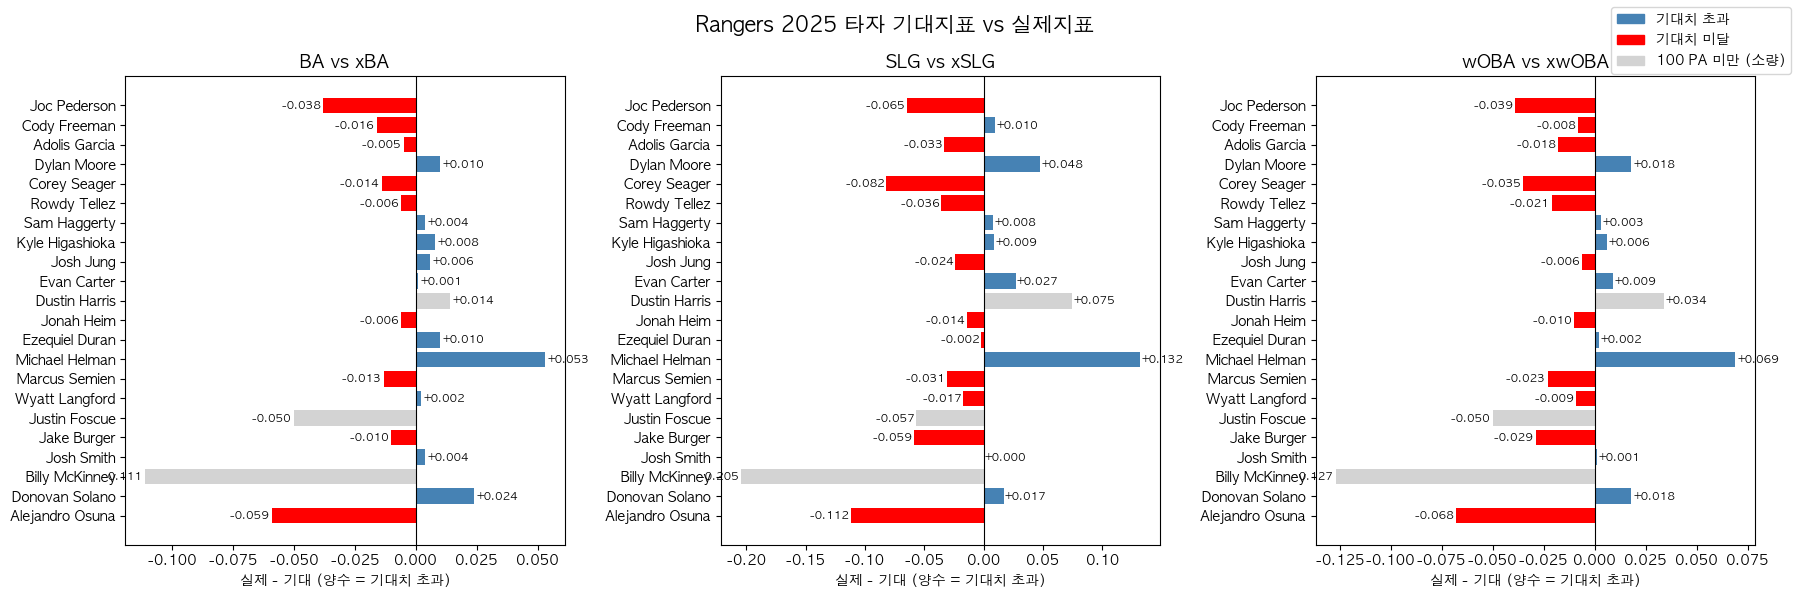

In [11]:
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = [
    ('BA', 'xBA', 'BA_diff', 'BA vs xBA'),
    ('SLG', 'xSLG', 'SLG_diff', 'SLG vs xSLG'),
    ('wOBA', 'xwOBA', 'wOBA_diff', 'wOBA vs xwOBA')
]

for ax, (actual, expected, diff, title) in zip(axes, metrics):
    colors = []
    for _, row in df_compare.iterrows():
        if row['PA'] < 100:
            colors.append('lightgray')  # 소량 타석 → 회색
        elif row[diff] < 0:
            colors.append('red')
        else:
            colors.append('steelblue')
    
    bars = ax.barh(df_compare['Player'], df_compare[diff], color=colors)
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('실제 - 기대 (양수 = 기대치 초과)')
    
    for bar, val in zip(bars, df_compare[diff]):
        ax.text(val + (0.001 if val >= 0 else -0.001),
                bar.get_y() + bar.get_height()/2,
                f'{val:+.3f}', va='center',
                ha='left' if val >= 0 else 'right', fontsize=8)

blue_patch = mpatches.Patch(color='steelblue', label='기대치 초과')
red_patch = mpatches.Patch(color='red', label='기대치 미달')
gray_patch = mpatches.Patch(color='lightgray', label='100 PA 미만 (소량)')
fig.legend(handles=[blue_patch, red_patch, gray_patch], loc='upper right')

plt.suptitle('Rangers 2025 타자 기대지표 vs 실제지표', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 시즌 팀 성적 추이

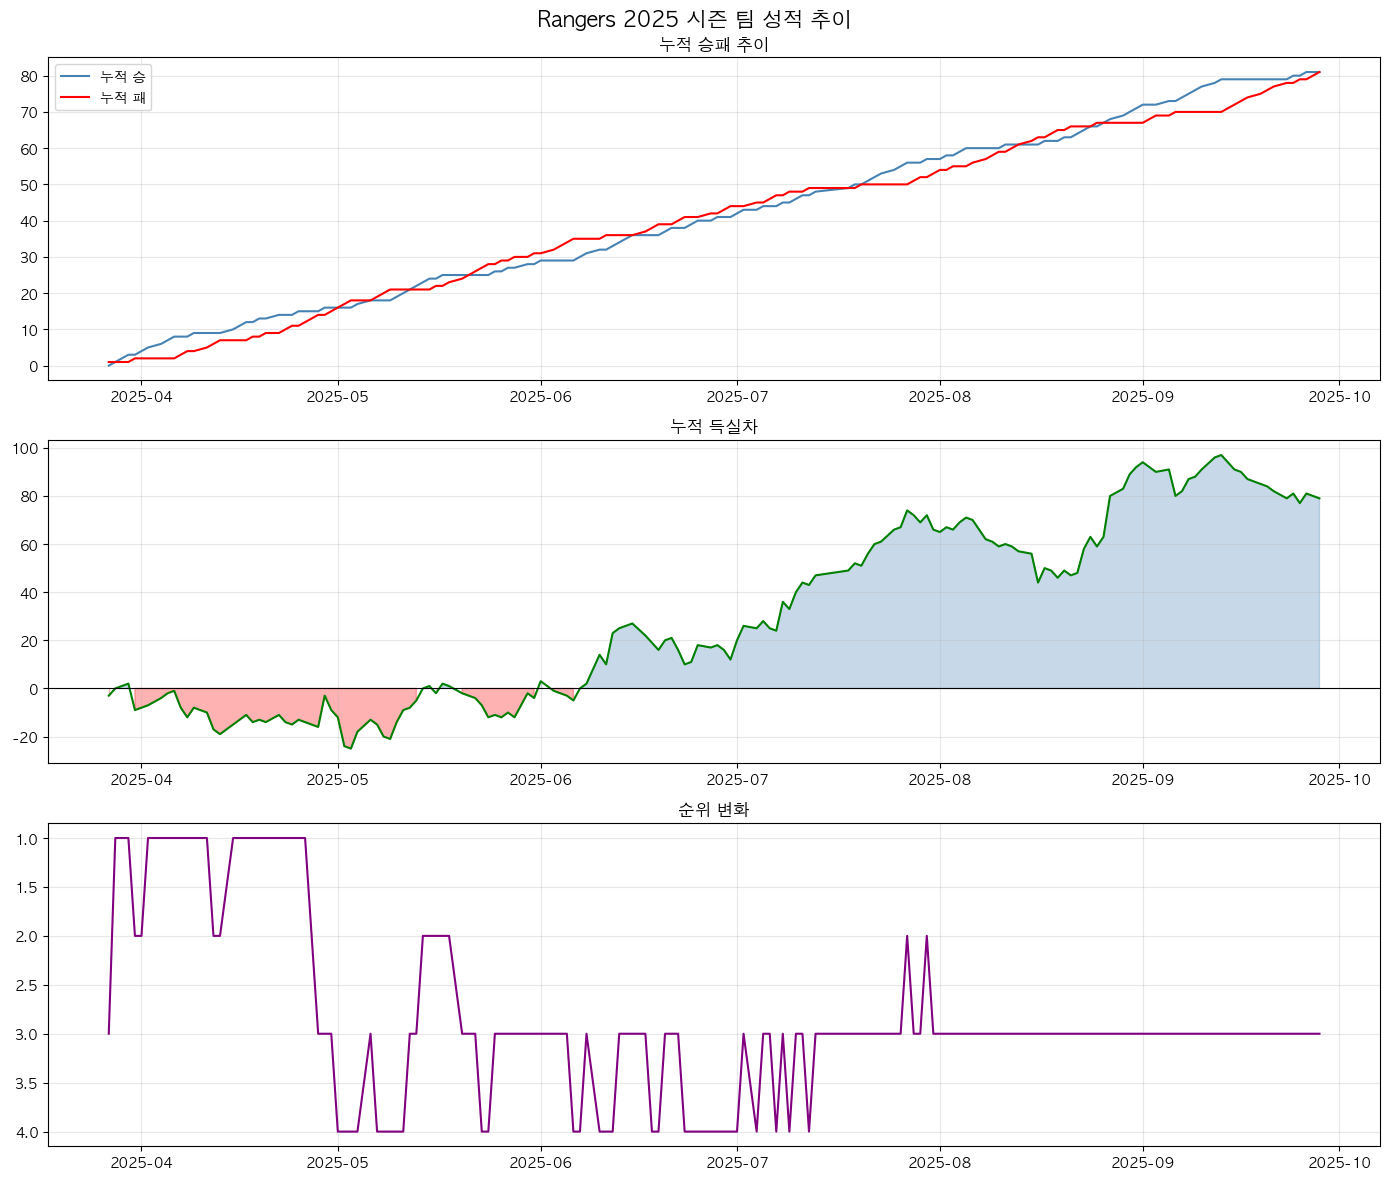

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

game_log = pd.read_csv('./data/texas_2025_game_log.csv')

# 날짜 파싱
game_log['Date'] = pd.to_datetime(game_log['Date'], format='%A, %b %d', errors='coerce')
game_log['Date'] = game_log['Date'].apply(lambda x: x.replace(year=2025) if pd.notnull(x) else x)

# 승패
game_log['win'] = game_log['W/L'].str.startswith('W').astype(int)
game_log['loss'] = game_log['W/L'].str.startswith('L').astype(int)

# 누적
game_log['cum_wins'] = game_log['win'].cumsum()
game_log['cum_losses'] = game_log['loss'].cumsum()
game_log['run_diff'] = game_log['R'] - game_log['RA']
game_log['cum_run_diff'] = game_log['run_diff'].cumsum()

# 시각화
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

axes[0].plot(game_log['Date'], game_log['cum_wins'], color='steelblue', label='누적 승')
axes[0].plot(game_log['Date'], game_log['cum_losses'], color='red', label='누적 패')
axes[0].set_title('누적 승패 추이', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(game_log['Date'], game_log['cum_run_diff'], color='green')
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].fill_between(game_log['Date'], game_log['cum_run_diff'], 0,
                     where=game_log['cum_run_diff'] >= 0, color='steelblue', alpha=0.3)
axes[1].fill_between(game_log['Date'], game_log['cum_run_diff'], 0,
                     where=game_log['cum_run_diff'] < 0, color='red', alpha=0.3)
axes[1].set_title('누적 득실차', fontweight='bold')
axes[1].grid(alpha=0.3)

axes[2].plot(game_log['Date'], game_log['Rank'], color='purple')
axes[2].invert_yaxis()
axes[2].set_title('순위 변화', fontweight='bold')
axes[2].grid(alpha=0.3)

plt.suptitle('Rangers 2025 시즌 팀 성적 추이', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 월별 기록

In [13]:
game_log['month'] = game_log['Date'].dt.month
monthly = game_log.groupby('month').agg(
    wins=('win', 'sum'),
    losses=('loss', 'sum'),
    run_diff=('run_diff', 'sum')
).reset_index()
display(monthly)

,month,wins,losses,run_diff
0,3,3,2,-9.0
1,4,13,13,0.0
2,5,12,16,5.0
3,6,13,13,16.0
4,7,16,9,54.0
5,8,14,14,26.0
6,9,10,14,-13.0


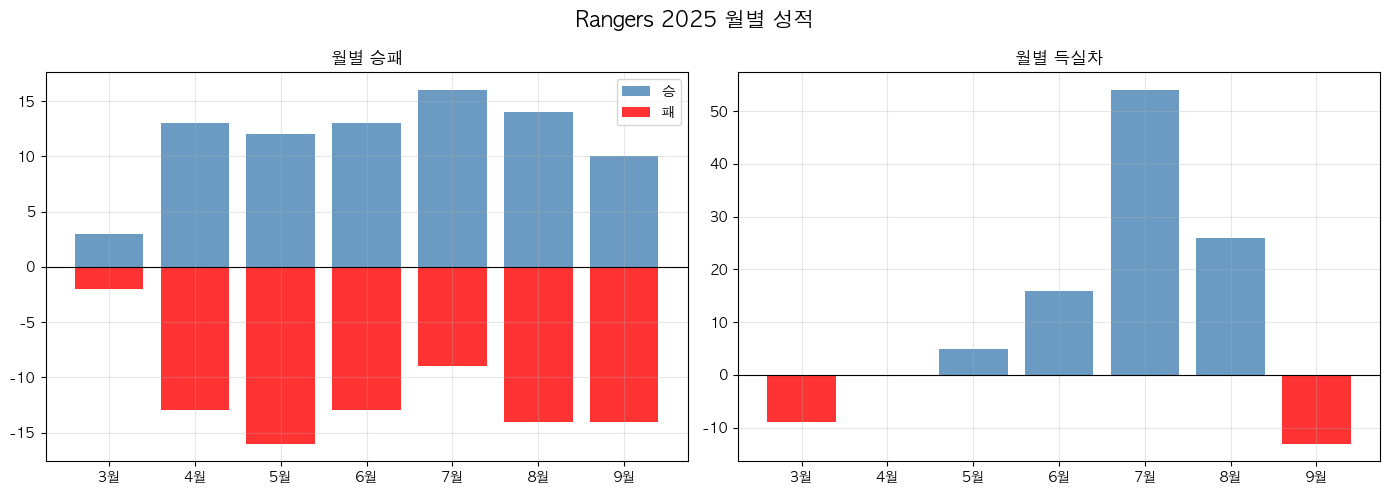

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

month_names = {3:'3월', 4:'4월', 5:'5월', 6:'6월', 7:'7월', 8:'8월', 9:'9월'}
monthly['month_name'] = monthly['month'].map(month_names)

# 월별 승패
x = range(len(monthly))
axes[0].bar(x, monthly['wins'], color='steelblue', label='승', alpha=0.8)
axes[0].bar(x, -monthly['losses'], color='red', label='패', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(monthly['month_name'])
axes[0].axhline(y=0, color='black', linewidth=0.8)
axes[0].set_title('월별 승패', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 월별 득실차
colors = ['steelblue' if x >= 0 else 'red' for x in monthly['run_diff']]
axes[1].bar(monthly['month_name'], monthly['run_diff'], color=colors, alpha=0.8)
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].set_title('월별 득실차', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.suptitle('Rangers 2025 월별 성적', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 선수 프로파일링

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["font.family"] = "AppleGothic"  # Mac 한글 폰트
plt.rcParams["axes.unicode_minus"] = False

# 데이터 로드
hit_stat  = pd.read_csv("./data/rangers_hitting_statcast.csv")
hit_bat   = pd.read_csv("./data/rangers_hitting_batted.csv")
hit_dis   = pd.read_csv("./data/rangers_hitting_discipline.csv")
pit_stat  = pd.read_csv("./data/rangers_pitching_statcast.csv")
pit_bat   = pd.read_csv("./data/rangers_pitching_batted.csv")
pit_dis   = pd.read_csv("./data/rangers_pitching_discipline.csv")
tex_wrc   = pd.read_csv("./data/tex_wrc+.csv")
running   = pd.read_csv("./data/rangers_running.csv")

# wRC+ 소수점 정리 & Unnamed 제거
tex_wrc["wRC+"] = tex_wrc["wRC+"].round(1)
tex_wrc = tex_wrc.drop(columns=[c for c in tex_wrc.columns if "Unnamed" in c])

print("데이터 로드 완료")
print(f"타자: {len(hit_stat)}명 | 투수: {len(pit_stat)}명")


데이터 로드 완료
타자: 22명 | 투수: 21명


## 타자 프로파일

In [16]:
# 타자 통합 데이터프레임
batter = hit_stat[[
    "Player", "PA", "BA", "OBP", "SLG", "wOBA",
    "Barrel %", "Hard Hit %", "Exit Velocity", "Launch Angle",
    "xBA", "xSLG", "xwOBA"
]].copy()

batter = batter.merge(
    hit_bat[["Player", "GB %", "FB %", "LD %", "PU %",
             "Pull %", "Straight %", "Oppo %", "Barrel %"]].rename(columns={"Barrel %": "Barrel %_bat"}),
    on="Player", how="left"
)
batter = batter.merge(
    hit_dis[["Player", "Zone %", "Chase %", "Whiff %", "Swing %",
             "Zone Contact %", "Chase Contact %"]],
    on="Player", how="left"
)
batter = batter.merge(
    tex_wrc[["Name", "wRC+"]].rename(columns={"Name": "Player"}),
    on="Player", how="left"
)
batter = batter.merge(
    running[["Player", "Sprint Speed (ft/s)"]],
    on="Player", how="left"
)

# ISO 계산
batter["ISO"] = (batter["SLG"] - batter["BA"]).round(3)

# wOBA 행운 지표 (실제 - 예측, 양수면 운 좋음)
batter["luck"] = (batter["wOBA"] - batter["xwOBA"]).round(3)

display(batter[["Player", "PA", "wRC+", "wOBA", "xwOBA", "luck", "Barrel %", "Chase %", "Whiff %"]]
      .sort_values("wRC+", ascending=False))


,Player,PA,wRC+,wOBA,xwOBA,luck,Barrel %,Chase %,Whiff %
17,Corey Seager,445,137.7,0.365,0.400,-0.035,15.3,23.0,27.9
6,Wyatt Langford,573,118.2,0.337,0.346,-0.009,14.0,23.4,26.3
16,Rowdy Tellez,312,114.8,0.307,0.328,-0.021,15.3,30.1,28.1
18,Dylan Moore,243,113.3,0.280,0.262,0.018,8.6,24.8,33.3
12,Evan Carter,220,107.3,0.321,0.312,0.009,5.9,20.0,25.5
8,Michael Helman,110,106.0,0.319,0.250,0.069,8.6,33.1,24.1
3,Josh Smith,563,100.3,0.311,0.310,0.001,5.0,25.7,19.6
15,Sam Haggerty,182,97.6,0.307,0.304,0.003,2.4,27.2,26.3
14,Kyle Higashioka,327,93.0,0.301,0.295,0.006,8.6,27.5,21.9
13,Josh Jung,511,91.2,0.298,0.304,-0.006,8.2,33.2,25.4


In [17]:
# 타자 유형 분류
# MLB 2025 평균: BA=0.245, ISO=0.159, Barrel%=8.6, Chase%=28.2, Whiff%=25.3
def classify_batter(row):
    power   = row["Barrel %"] >= 8.6  or row["ISO"] >= 0.159
    contact = row["BA"]       >= 0.245 and row["Whiff %"] <= 25.3
    eye     = row["Chase %"]  <= 28.2  and row["Whiff %"] <= 25.3
    if power and eye:    return "파워+선구안"
    if power:            return "파워형"
    if contact and eye:  return "컨택+선구안"
    if contact:          return "컨택형"
    if eye:              return "선구안형"
    return "평균형"

batter["유형"] = batter.apply(classify_batter, axis=1)

display(batter[["Player", "유형", "wRC+", "Barrel %", "ISO", "BA", "Chase %", "Whiff %"]]
      .sort_values("wRC+", ascending=False))


,Player,유형,wRC+,Barrel %,ISO,BA,Chase %,Whiff %
17,Corey Seager,파워형,137.7,15.3,0.216,0.271,23.0,27.9
6,Wyatt Langford,파워형,118.2,14.0,0.190,0.241,23.4,26.3
16,Rowdy Tellez,파워형,114.8,15.3,0.215,0.228,30.1,28.1
18,Dylan Moore,파워형,113.3,8.6,0.173,0.201,24.8,33.3
12,Evan Carter,평균형,107.3,5.9,0.145,0.247,20.0,25.5
8,Michael Helman,파워형,106.0,8.6,0.223,0.232,33.1,24.1
3,Josh Smith,컨택+선구안,100.3,5.0,0.115,0.251,25.7,19.6
15,Sam Haggerty,평균형,97.6,2.4,0.117,0.253,27.2,26.3
14,Kyle Higashioka,파워+선구안,93.0,8.6,0.162,0.241,27.5,21.9
13,Josh Jung,평균형,91.2,8.2,0.139,0.251,33.2,25.4


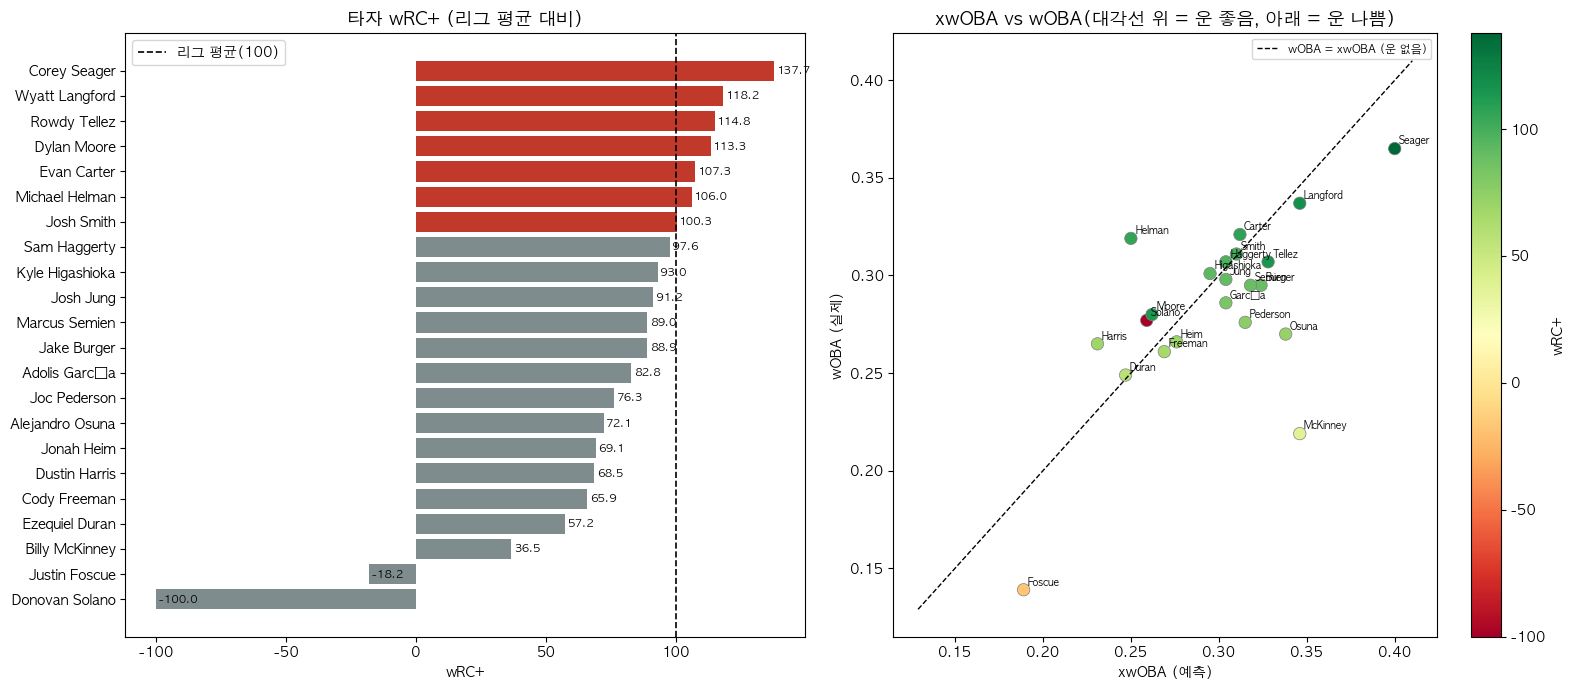

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- 왼쪽: wRC+ 바차트 (100 기준선)
df_plot = batter[["Player", "wRC+"]].dropna().sort_values("wRC+", ascending=True)
colors = ["#c0392b" if v >= 100 else "#7f8c8d" for v in df_plot["wRC+"]]
axes[0].barh(df_plot["Player"], df_plot["wRC+"], color=colors)
axes[0].axvline(100, color="black", linestyle="--", linewidth=1.2, label="리그 평균(100)")
axes[0].set_title("타자 wRC+ (리그 평균 대비)", fontsize=13)
axes[0].set_xlabel("wRC+")
axes[0].legend()
for i, (v, name) in enumerate(zip(df_plot["wRC+"], df_plot["Player"])):
    axes[0].text(v + 1, i, f"{v:.1f}", va="center", fontsize=8)

# --- 오른쪽: xwOBA vs wOBA (운 산점도)
df_luck = batter[["Player", "wOBA", "xwOBA", "wRC+"]].dropna()
sc = axes[1].scatter(df_luck["xwOBA"], df_luck["wOBA"],
                     c=df_luck["wRC+"], cmap="RdYlGn", s=80, edgecolors="grey", linewidth=0.5)
plt.colorbar(sc, ax=axes[1], label="wRC+")
mn = min(df_luck["xwOBA"].min(), df_luck["wOBA"].min()) - 0.01
mx = max(df_luck["xwOBA"].max(), df_luck["wOBA"].max()) + 0.01
axes[1].plot([mn, mx], [mn, mx], "k--", linewidth=1, label="wOBA = xwOBA (운 없음)")
for _, row in df_luck.iterrows():
    axes[1].annotate(row["Player"].split()[-1], (row["xwOBA"], row["wOBA"]),
                     fontsize=7, xytext=(3, 3), textcoords="offset points")
axes[1].set_xlabel("xwOBA (예측)")
axes[1].set_ylabel("wOBA (실제)")
axes[1].set_title("xwOBA vs wOBA(대각선 위 = 운 좋음, 아래 = 운 나쁨)", fontsize=13)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


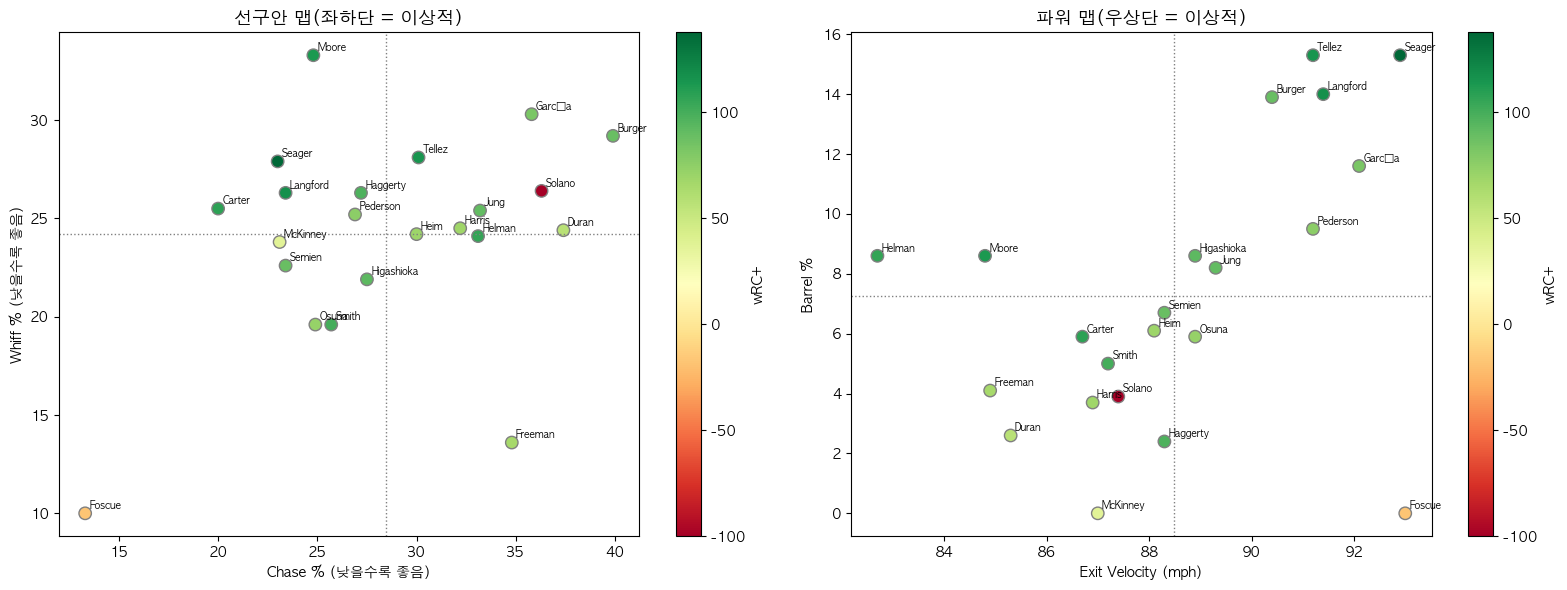

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- 왼쪽: Chase% vs Whiff% (선구안 맵)
df_eye = batter[["Player", "Chase %", "Whiff %", "wRC+"]].dropna()
sc = axes[0].scatter(df_eye["Chase %"], df_eye["Whiff %"],
                     c=df_eye["wRC+"], cmap="RdYlGn", s=80, edgecolors="grey")
plt.colorbar(sc, ax=axes[0], label="wRC+")
axes[0].axvline(df_eye["Chase %"].mean(), color="grey", linestyle=":", linewidth=1)
axes[0].axhline(df_eye["Whiff %"].mean(), color="grey", linestyle=":", linewidth=1)
for _, row in df_eye.iterrows():
    axes[0].annotate(row["Player"].split()[-1], (row["Chase %"], row["Whiff %"]),
                     fontsize=7, xytext=(3, 3), textcoords="offset points")
axes[0].set_xlabel("Chase % (낮을수록 좋음)")
axes[0].set_ylabel("Whiff % (낮을수록 좋음)")
axes[0].set_title("선구안 맵(좌하단 = 이상적)", fontsize=13)

# --- 오른쪽: EV vs Barrel% (파워 맵)
df_pow = batter[["Player", "Exit Velocity", "Barrel %", "wRC+"]].dropna()
sc = axes[1].scatter(df_pow["Exit Velocity"], df_pow["Barrel %"],
                     c=df_pow["wRC+"], cmap="RdYlGn", s=80, edgecolors="grey")
plt.colorbar(sc, ax=axes[1], label="wRC+")
axes[1].axvline(df_pow["Exit Velocity"].mean(), color="grey", linestyle=":", linewidth=1)
axes[1].axhline(df_pow["Barrel %"].mean(), color="grey", linestyle=":", linewidth=1)
for _, row in df_pow.iterrows():
    axes[1].annotate(row["Player"].split()[-1], (row["Exit Velocity"], row["Barrel %"]),
                     fontsize=7, xytext=(3, 3), textcoords="offset points")
axes[1].set_xlabel("Exit Velocity (mph)")
axes[1].set_ylabel("Barrel %")
axes[1].set_title("파워 맵(우상단 = 이상적)", fontsize=13)

plt.tight_layout()
plt.show()


## 투수 프로파일

In [21]:
# 투수 통합 데이터프레임
pitcher = pit_stat[[
    "Player", "PA", "BA", "OBP", "SLG", "wOBA",
    "Barrel %", "Hard Hit %", "Exit Velocity", "xBA", "xwOBA"
]].copy()

pitcher = pitcher.merge(
    pit_bat[["Player", "GB %", "FB %", "LD %", "Pull %", "Oppo %"]],
    on="Player", how="left"
)
pitcher = pitcher.merge(
    pit_dis[["Player", "Zone %", "Chase %", "Whiff %", "Swing %"]],
    on="Player", how="left"
)

# 타구 억제력: 실제 wOBA - xwOBA (음수면 실제보다 잘 막은 것)
pitcher["luck"] = (pitcher["wOBA"] - pitcher["xwOBA"]).round(3)

display(pitcher[["Player", "PA", "wOBA", "xwOBA", "luck", "Barrel %", "Hard Hit %", "Whiff %"]]
      .sort_values("xwOBA", ascending=True))

,Player,PA,wOBA,xwOBA,luck,Barrel %,Hard Hit %,Whiff %
16,Phil Maton,249,0.266,0.264,0.002,3.6,30.7,36.2
0,Nathan Eovaldi,496,0.240,0.272,-0.032,7.4,38.5,27.7
19,Shawn Armstrong,284,0.224,0.272,-0.048,7.1,34.2,24.4
6,Jacob Webb,267,0.270,0.281,-0.011,5.9,34.6,27.6
20,Jacob deGrom,669,0.259,0.286,-0.027,9.2,41.9,30.2
14,Luis Curvelo,84,0.324,0.299,0.025,9.3,35.2,22.4
11,Hoby Milner,293,0.298,0.303,-0.005,9.0,36.8,15.5
13,Chris Martin,173,0.291,0.303,-0.012,9.0,41.0,21.8
15,Robert Garcia,269,0.295,0.304,-0.009,7.9,34.3,28.6
12,Danny Coulombe,176,0.261,0.309,-0.048,5.2,38.3,27.7


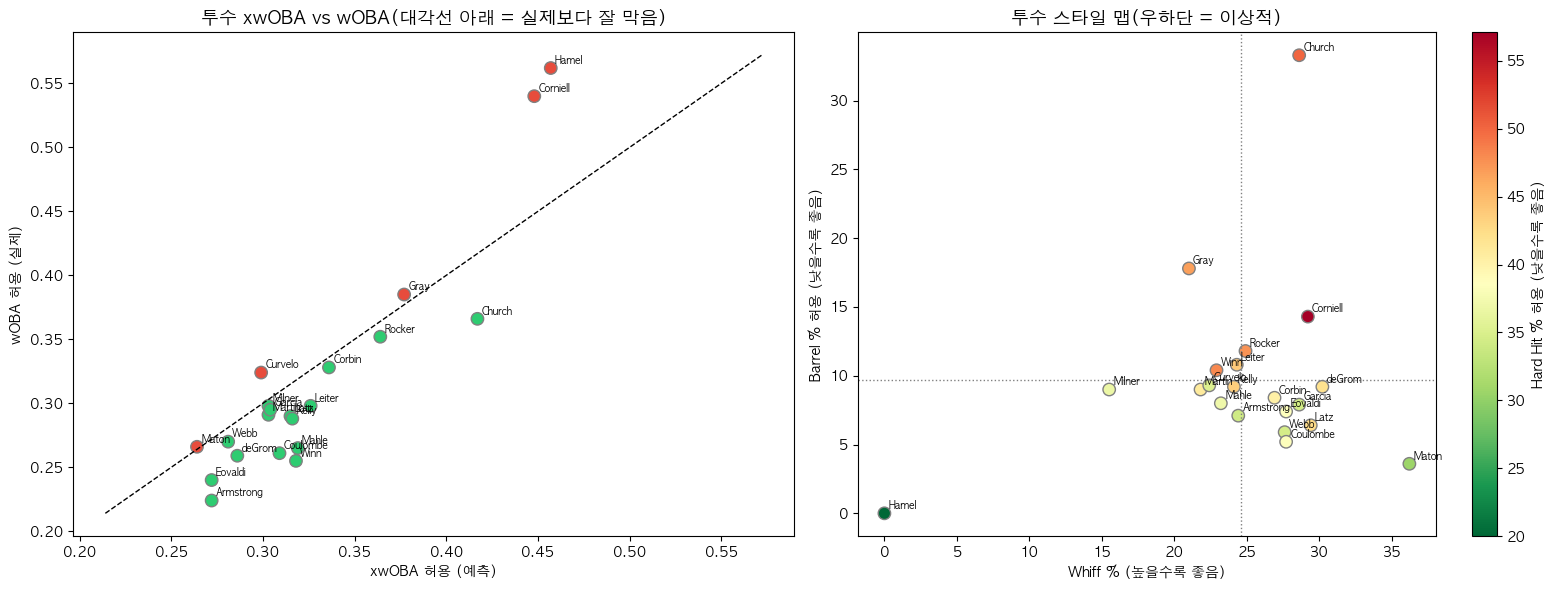

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- 왼쪽: xwOBA vs wOBA (투수 운/실력 분리)
df_p = pitcher[["Player", "wOBA", "xwOBA", "PA"]].dropna()
colors_p = ["#2ecc71" if (w - xw) < 0 else "#e74c3c"
            for w, xw in zip(df_p["wOBA"], df_p["xwOBA"])]
axes[0].scatter(df_p["xwOBA"], df_p["wOBA"], c=colors_p, s=80, edgecolors="grey")
mn = min(df_p["xwOBA"].min(), df_p["wOBA"].min()) - 0.01
mx = max(df_p["xwOBA"].max(), df_p["wOBA"].max()) + 0.01
axes[0].plot([mn, mx], [mn, mx], "k--", linewidth=1)
for _, row in df_p.iterrows():
    axes[0].annotate(row["Player"].split()[-1], (row["xwOBA"], row["wOBA"]),
                     fontsize=7, xytext=(3, 3), textcoords="offset points")
axes[0].set_xlabel("xwOBA 허용 (예측)")
axes[0].set_ylabel("wOBA 허용 (실제)")
axes[0].set_title("투수 xwOBA vs wOBA(대각선 아래 = 실제보다 잘 막음)", fontsize=13)

# --- 오른쪽: Whiff% vs Barrel% 허용 (삼진형 vs 타구 억제형)
df_p2 = pitcher[["Player", "Whiff %", "Barrel %", "Hard Hit %"]].dropna()
sc = axes[1].scatter(df_p2["Whiff %"], df_p2["Barrel %"],
                     c=df_p2["Hard Hit %"], cmap="RdYlGn_r", s=80, edgecolors="grey")
plt.colorbar(sc, ax=axes[1], label="Hard Hit % 허용 (낮을수록 좋음)")
axes[1].axvline(df_p2["Whiff %"].mean(), color="grey", linestyle=":", linewidth=1)
axes[1].axhline(df_p2["Barrel %"].mean(), color="grey", linestyle=":", linewidth=1)
for _, row in df_p2.iterrows():
    axes[1].annotate(row["Player"].split()[-1], (row["Whiff %"], row["Barrel %"]),
                     fontsize=7, xytext=(3, 3), textcoords="offset points")
axes[1].set_xlabel("Whiff % (높을수록 좋음)")
axes[1].set_ylabel("Barrel % 허용 (낮을수록 좋음)")
axes[1].set_title("투수 스타일 맵(우하단 = 이상적)", fontsize=13)

plt.tight_layout()
plt.show()


In [23]:
# 투수 유형 분류
def classify_pitcher(row):
    k_type   = row["Whiff %"] >= 27
    gb_type  = row["GB %"] >= 45
    suppress = row["Barrel %"] <= 7 and row["Hard Hit %"] <= 38
    if k_type and suppress:   return "탈삼진+타구억제"
    if k_type:                return "탈삼진형"
    if gb_type and suppress:  return "땅볼+타구억제"
    if gb_type:               return "땅볼형"
    if suppress:              return "타구억제형"
    return "평균형"

pitcher["유형"] = pitcher.apply(classify_pitcher, axis=1)

display(pitcher[["Player", "유형", "xwOBA", "wOBA", "Whiff %", "GB %", "Barrel %", "Hard Hit %"]]
      .sort_values("xwOBA", ascending=True))

,Player,유형,xwOBA,wOBA,Whiff %,GB %,Barrel %,Hard Hit %
16,Phil Maton,탈삼진+타구억제,0.264,0.266,36.2,46.0,3.6,30.7
0,Nathan Eovaldi,탈삼진형,0.272,0.240,27.7,51.2,7.4,38.5
19,Shawn Armstrong,평균형,0.272,0.224,24.4,35.9,7.1,34.2
6,Jacob Webb,탈삼진+타구억제,0.281,0.270,27.6,33.5,5.9,34.6
20,Jacob deGrom,탈삼진형,0.286,0.259,30.2,38.1,9.2,41.9
14,Luis Curvelo,평균형,0.299,0.324,22.4,25.9,9.3,35.2
11,Hoby Milner,땅볼형,0.303,0.298,15.5,53.8,9.0,36.8
13,Chris Martin,평균형,0.303,0.291,21.8,43.4,9.0,41.0
15,Robert Garcia,탈삼진형,0.304,0.295,28.6,39.9,7.9,34.3
12,Danny Coulombe,탈삼진형,0.309,0.261,27.7,41.7,5.2,38.3


## 불펜/마무리 투수 평가

In [30]:
import pandas as pd
import numpy as np

pitcher_gl = pd.read_csv("./data/rangers_pitcher_gamelogs.csv")

# 순수 불펜 (선발 등판 없는 선수)
gs_sum = pitcher_gl.groupby("name")["GS"].sum()
bullpen_names = gs_sum[gs_sum == 0].index.tolist()

# 집계
agg = pitcher_gl[pitcher_gl["name"].isin(bullpen_names)].groupby("name").agg(
    G=("G", "sum"), SV=("SV", "sum"),
    IP=("IP", "sum"), H=("H", "sum"),
    BB=("BB", "sum"), SO=("SO", "sum"),
    R=("R", "sum"), ER=("ER", "sum"), HR=("HR", "sum")
).reset_index()

# IP 소수 → 실제 이닝 변환 (0.1 = 1/3)
agg["IP_float"] = agg["IP"].apply(lambda x: int(x) + (x % 1) / 0.3).round(2)

# ERA, FIP, BB/9, K/9
agg["ERA"]  = (agg["ER"] * 9 / agg["IP_float"]).round(2)
agg["FIP"]  = ((13*agg["HR"] + 3*agg["BB"] - 2*agg["SO"]) / agg["IP_float"] + 3.10).round(2)
agg["BB9"]  = (agg["BB"] * 9 / agg["IP_float"]).round(2)
agg["K9"]   = (agg["SO"] * 9 / agg["IP_float"]).round(2)
agg["ERA-FIP"] = (agg["ERA"] - agg["FIP"]).round(2)  # 양수 = 실제보다 나빴음(운 없음)

# Statcast 지표 병합 (xwOBA, Whiff%, Barrel%, Hard Hit%)
stat_cols = pit_stat[["Player", "xwOBA", "Barrel %", "Hard Hit %"]].rename(columns={"Player": "name"})
dis_cols  = pit_dis[["Player", "Whiff %", "Chase %", "Zone %"]].rename(columns={"Player": "name"})
agg = agg.merge(stat_cols, on="name", how="left")
agg = agg.merge(dis_cols, on="name", how="left")

# IP 10이닝 미만 제외 (소규모 샘플)
agg_main = agg[agg["IP_float"] >= 10].copy()

display(agg_main[[
    "name", "G", "SV", "IP_float", "ERA", "FIP", "ERA-FIP",
    "BB9", "K9", "xwOBA", "Whiff %", "Barrel %"
]].sort_values("FIP", ascending=True))


,name,G,SV,IP_float,ERA,FIP,ERA-FIP,BB9,K9,xwOBA,Whiff %,Barrel %
14,Phil Maton,23,3,20.67,3.92,2.33,1.59,3.48,14.37,0.264,36.2,3.6
7,Hoby Milner,73,0,58.67,4.60,3.30,1.30,3.22,8.90,0.303,15.5,9.0
1,Chris Martin,49,2,35.33,3.57,3.55,0.02,2.04,10.95,0.303,21.8,9.0
3,Cole Winn,33,0,37.00,1.70,3.64,-1.94,4.14,8.51,0.318,22.9,10.4
15,Robert Garcia,71,9,54.67,3.46,3.72,-0.26,3.62,11.19,0.304,28.6,7.9
8,Jacob Webb,55,1,59.00,3.36,4.30,-0.94,2.90,8.85,0.281,27.6,5.9
12,Luke Jackson,52,9,46.33,4.47,4.40,0.07,5.44,7.38,NaN,NaN,NaN
4,Dane Dunning,12,2,20.67,6.97,4.60,2.37,3.05,9.14,NaN,NaN,NaN
11,Luis Curvelo,17,0,19.00,5.68,4.63,1.05,4.74,9.47,0.299,22.4,9.3
9,Jon Gray,6,0,14.00,7.71,7.31,0.40,3.86,7.71,0.377,21.0,17.8


In [31]:
# 불안정 등판 빈도 (IP=0)
ip0_count = pitcher_gl[pitcher_gl["name"].isin(bullpen_names)].groupby("name").apply(
    lambda x: (x["IP"] == 0).sum()
).rename("IP0_count")
ip0_rate = pitcher_gl[pitcher_gl["name"].isin(bullpen_names)].groupby("name").apply(
    lambda x: round((x["IP"] == 0).sum() / len(x) * 100, 1)
).rename("IP0_pct")

unstable = pd.concat([ip0_count, ip0_rate], axis=1).reset_index()
unstable = unstable.merge(agg[["name", "G", "SV", "ERA", "FIP"]], on="name", how="left")
display(unstable[unstable["G"] >= 10].sort_values("IP0_pct", ascending=False))


,name,IP0_count,IP0_pct,G,SV,ERA,FIP
4,Dane Dunning,1,8.3,12,2,6.97,4.60
7,Hoby Milner,6,8.2,73,0,4.60,3.30
5,Danny Coulombe,1,6.7,15,0,6.51,7.44
1,Chris Martin,3,6.1,49,2,3.57,3.55
11,Luis Curvelo,1,5.9,17,0,5.68,4.63
12,Luke Jackson,3,5.8,52,9,4.47,4.40
15,Robert Garcia,1,1.4,71,9,3.46,3.72
3,Cole Winn,0,0.0,33,0,1.70,3.64
8,Jacob Webb,0,0.0,55,1,3.36,4.30
14,Phil Maton,0,0.0,23,3,3.92,2.33


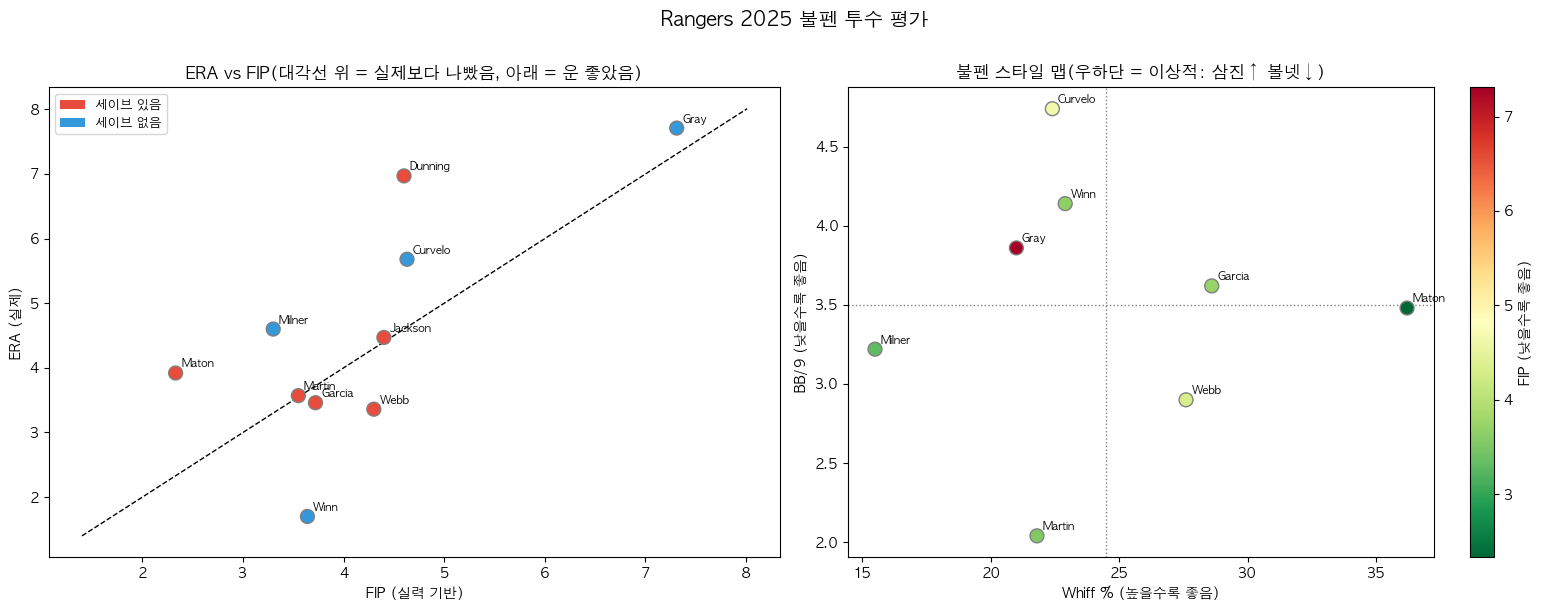

In [32]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- 왼쪽: ERA vs FIP (운/수비 영향 분리)
df_ef = agg_main[["name", "ERA", "FIP", "SV"]].dropna()
colors_ef = ["#e74c3c" if sv > 0 else "#3498db" for sv in df_ef["SV"]]
axes[0].scatter(df_ef["FIP"], df_ef["ERA"], c=colors_ef, s=100, edgecolors="grey", zorder=3)
mn = min(df_ef["FIP"].min(), df_ef["ERA"].min()) - 0.3
mx = max(df_ef["FIP"].max(), df_ef["ERA"].max()) + 0.3
axes[0].plot([mn, mx], [mn, mx], "k--", linewidth=1, label="ERA = FIP")
for _, row in df_ef.iterrows():
    axes[0].annotate(row["name"].split()[-1], (row["FIP"], row["ERA"]),
                     fontsize=8, xytext=(4, 4), textcoords="offset points")
axes[0].set_xlabel("FIP (실력 기반)")
axes[0].set_ylabel("ERA (실제)")
axes[0].set_title("ERA vs FIP(대각선 위 = 실제보다 나빴음, 아래 = 운 좋았음)", fontsize=12)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#e74c3c", label="세이브 있음"),
                   Patch(facecolor="#3498db", label="세이브 없음")]
axes[0].legend(handles=legend_elements, fontsize=9)

# --- 오른쪽: Whiff% vs BB/9 (삼진 유도 vs 제구)
df_kb = agg_main[["name", "Whiff %", "BB9", "SV", "FIP"]].dropna()
sc = axes[1].scatter(df_kb["Whiff %"], df_kb["BB9"],
                     c=df_kb["FIP"], cmap="RdYlGn_r", s=100, edgecolors="grey", zorder=3)
plt.colorbar(sc, ax=axes[1], label="FIP (낮을수록 좋음)")
axes[1].axvline(df_kb["Whiff %"].mean(), color="grey", linestyle=":", linewidth=1)
axes[1].axhline(df_kb["BB9"].mean(), color="grey", linestyle=":", linewidth=1)
for _, row in df_kb.iterrows():
    axes[1].annotate(row["name"].split()[-1], (row["Whiff %"], row["BB9"]),
                     fontsize=8, xytext=(4, 4), textcoords="offset points")
axes[1].set_xlabel("Whiff % (높을수록 좋음)")
axes[1].set_ylabel("BB/9 (낮을수록 좋음)")
axes[1].set_title("불펜 스타일 맵(우하단 = 이상적: 삼진↑ 볼넷↓)", fontsize=12)

plt.suptitle("Rangers 2025 불펜 투수 평가", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## 상대팀별 매치업 성적 (Opponent Splits)

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

batter_gl  = pd.read_csv("./data/rangers_batter_gamelogs.csv")
pitcher_gl = pd.read_csv("./data/rangers_pitcher_gamelogs.csv")

def get_opponent(row):
    return row["Away Tm"] if row["Home Tm"] == "Texas Rangers" else row["Home Tm"]

batter_gl["opponent"]  = batter_gl.apply(get_opponent, axis=1)
pitcher_gl["opponent"] = pitcher_gl.apply(get_opponent, axis=1)

bat_game = batter_gl.groupby(["Date", "opponent"]).agg(R_scored=("R", "sum")).reset_index()
pit_game = pitcher_gl.groupby(["Date", "opponent"]).agg(R_allowed=("R", "sum")).reset_index()
games = bat_game.merge(pit_game, on=["Date", "opponent"], how="inner")
games["win"] = (games["R_scored"] > games["R_allowed"]).astype(int)

by_opp = games.groupby("opponent").agg(
    G=("Date", "count"), W=("win", "sum"),
    R_scored=("R_scored", "sum"), R_allowed=("R_allowed", "sum")
).reset_index()
by_opp["L"]       = by_opp["G"] - by_opp["W"]
by_opp["득실차"]   = by_opp["R_scored"] - by_opp["R_allowed"]
by_opp["RS/G"]    = (by_opp["R_scored"]  / by_opp["G"]).round(2)
by_opp["RA/G"]    = (by_opp["R_allowed"] / by_opp["G"]).round(2)
by_opp["승률"]    = (by_opp["W"] / by_opp["G"]).round(3)

display(by_opp[["opponent", "G", "W", "L", "승률", "RS/G", "RA/G", "득실차"]]
      .sort_values("승률", ascending=False))


,opponent,G,W,L,승률,RS/G,RA/G,득실차
2,Atlanta Braves,3,3,0,1.000,7.33,3.00,13
16,Milwaukee Brewers,3,3,0,1.000,5.33,2.33,9
9,Colorado Rockies,3,3,0,1.000,4.67,1.67,9
28,Washington Nationals,3,2,1,0.667,3.00,1.33,5
8,Cleveland Guardians,6,4,2,0.667,6.00,3.00,18
18,New York Mets,3,2,1,0.667,4.33,3.33,3
25,St. Louis Cardinals,3,2,1,0.667,6.33,1.33,15
21,Pittsburgh Pirates,3,2,1,0.667,4.00,4.00,0
10,Detroit Tigers,6,4,2,0.667,4.00,1.50,15
7,Cincinnati Reds,3,2,1,0.667,1.67,4.67,-9


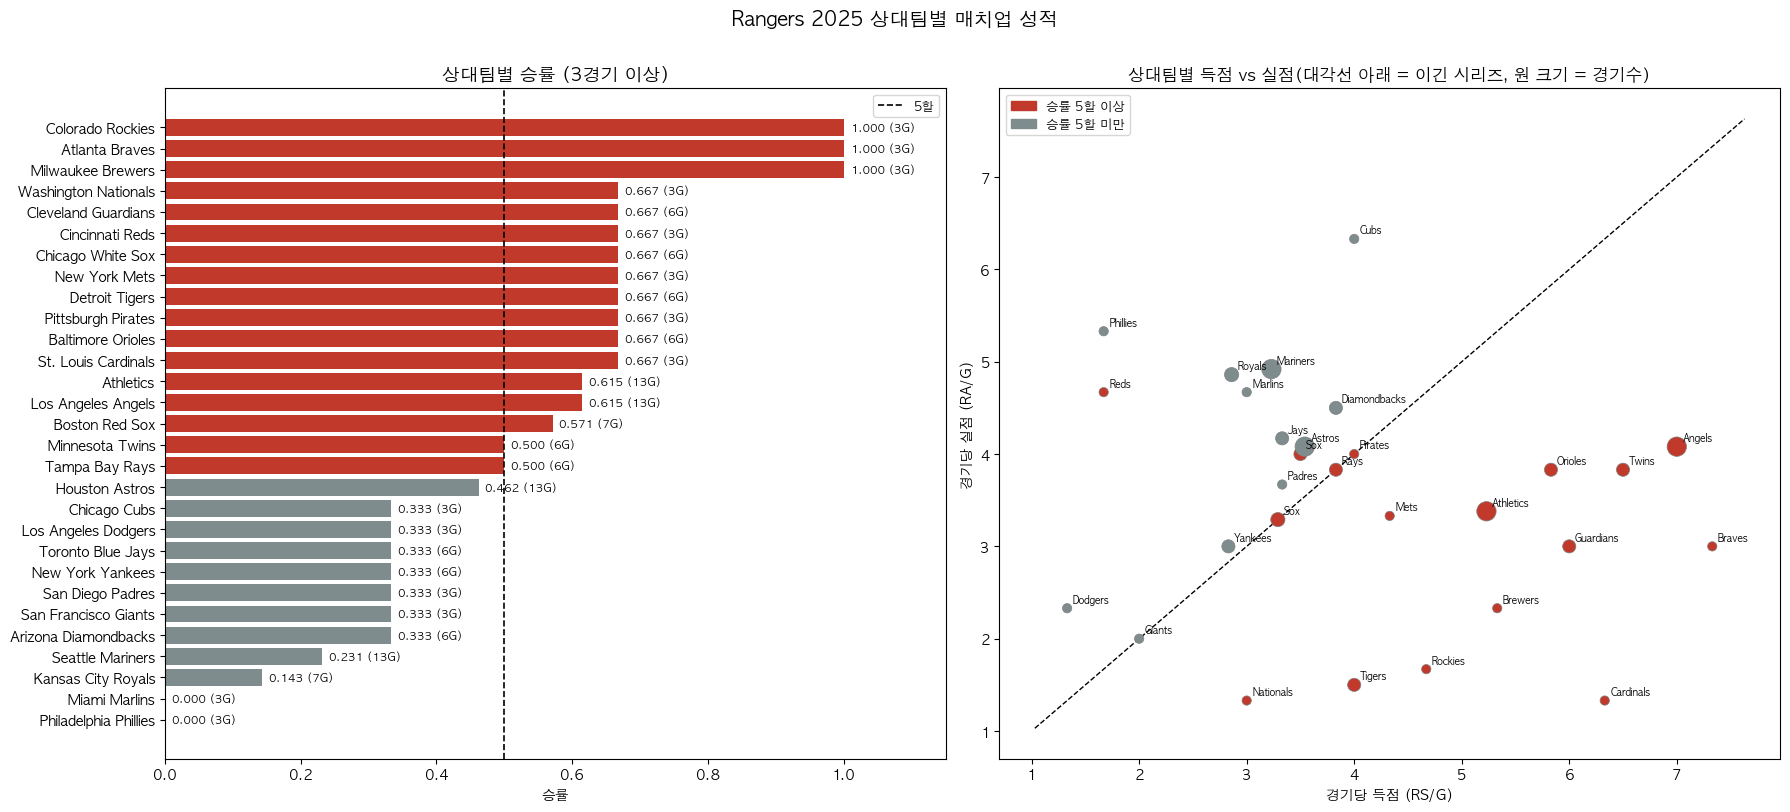

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- 왼쪽: 상대팀별 승률 바차트 (3경기 이상만)
df_plot = by_opp[by_opp["G"] >= 3].sort_values("승률", ascending=True).copy()
colors = ["#c0392b" if w >= 0.5 else "#7f8c8d" for w in df_plot["승률"]]
bars = axes[0].barh(df_plot["opponent"], df_plot["승률"], color=colors)
axes[0].axvline(0.5, color="black", linestyle="--", linewidth=1.2, label="5할")
for i, (v, g) in enumerate(zip(df_plot["승률"], df_plot["G"])):
    axes[0].text(v + 0.01, i, f"{v:.3f} ({g}G)", va="center", fontsize=8)
axes[0].set_xlim(0, 1.15)
axes[0].set_title("상대팀별 승률 (3경기 이상)", fontsize=13)
axes[0].set_xlabel("승률")
axes[0].legend(fontsize=9)

# --- 오른쪽: RS/G vs RA/G 산점도 (득점력 vs 실점)
df_s = by_opp[by_opp["G"] >= 3].copy()
win_colors = ["#c0392b" if w >= 0.5 else "#7f8c8d" for w in df_s["승률"]]
axes[1].scatter(df_s["RS/G"], df_s["RA/G"], c=win_colors, s=df_s["G"]*15,
                edgecolors="grey", linewidth=0.5, zorder=3)
mn = min(df_s["RS/G"].min(), df_s["RA/G"].min()) - 0.3
mx = max(df_s["RS/G"].max(), df_s["RA/G"].max()) + 0.3
axes[1].plot([mn, mx], [mn, mx], "k--", linewidth=1, label="득점=실점")
for _, row in df_s.iterrows():
    short = row["opponent"].split()[-1]
    axes[1].annotate(short, (row["RS/G"], row["RA/G"]),
                     fontsize=7, xytext=(4, 4), textcoords="offset points")
axes[1].set_xlabel("경기당 득점 (RS/G)")
axes[1].set_ylabel("경기당 실점 (RA/G)")
axes[1].set_title("상대팀별 득점 vs 실점(대각선 아래 = 이긴 시리즈, 원 크기 = 경기수)", fontsize=12)
win_patch = mpatches.Patch(color="#c0392b", label="승률 5할 이상")
lose_patch = mpatches.Patch(color="#7f8c8d", label="승률 5할 미만")
axes[1].legend(handles=[win_patch, lose_patch], fontsize=9)

plt.suptitle("Rangers 2025 상대팀별 매치업 성적", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## 팀 공격력 / 득점 패턴 / 클러치 분석

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

batter_gl  = pd.read_csv("./data/rangers_batter_gamelogs.csv")
pitcher_gl = pd.read_csv("./data/rangers_pitcher_gamelogs.csv")

bat_game = batter_gl.groupby("Date").agg(
    R=("R","sum"), H=("H","sum"), HR=("HR","sum"),
    BB=("BB","sum"), SO=("SO","sum")
).reset_index()
pit_game = pitcher_gl.groupby("Date").agg(R_allowed=("R","sum")).reset_index()
games = bat_game.merge(pit_game, on="Date")
games["win"]         = (games["R"] > games["R_allowed"]).astype(int)
games["Date"]        = pd.to_datetime(games["Date"])
games["month"]       = games["Date"].dt.month
games["score_diff"]  = games["R"] - games["R_allowed"]
games["close"]       = games["score_diff"].abs() <= 2

# 득점 구간별 승률
bins   = [-1, 0, 2, 4, 6, 8, 100]
labels = ["0", "1-2", "3-4", "5-6", "7-8", "9+"]
games["R_bin"] = pd.cut(games["R"], bins=bins, labels=labels)
score_wr = games.groupby("R_bin", observed=True).agg(
    경기수=("win","count"), 승=("win","sum")
).assign(승률=lambda x: (x["승"]/x["경기수"]).round(3))
print("=== 득점 구간별 승률 ===")
display(score_wr)
print()
print(f"접전(2점차이내) 승률: {games[games['close']]['win'].mean():.3f} ({games[games['close']].shape[0]}G)")
print(f"HR 있는 경기 승률:    {games[games['HR']>0]['win'].mean():.3f}")
print(f"HR 없는 경기 승률:    {games[games['HR']==0]['win'].mean():.3f}")
print(f"득점 표준편차:        {games['R'].std():.2f}")


=== 득점 구간별 승률 ===


,경기수,승,승률
R_bin,,,
0,15,0,0.000
1-2,43,8,0.186
3-4,41,18,0.439
5-6,32,24,0.750
7-8,18,16,0.889
9+,13,13,1.000



접전(2점차이내) 승률: 0.430 (79G)
HR 있는 경기 승률:    0.618
HR 없는 경기 승률:    0.267
득점 표준편차:        3.40


## 득점 패턴

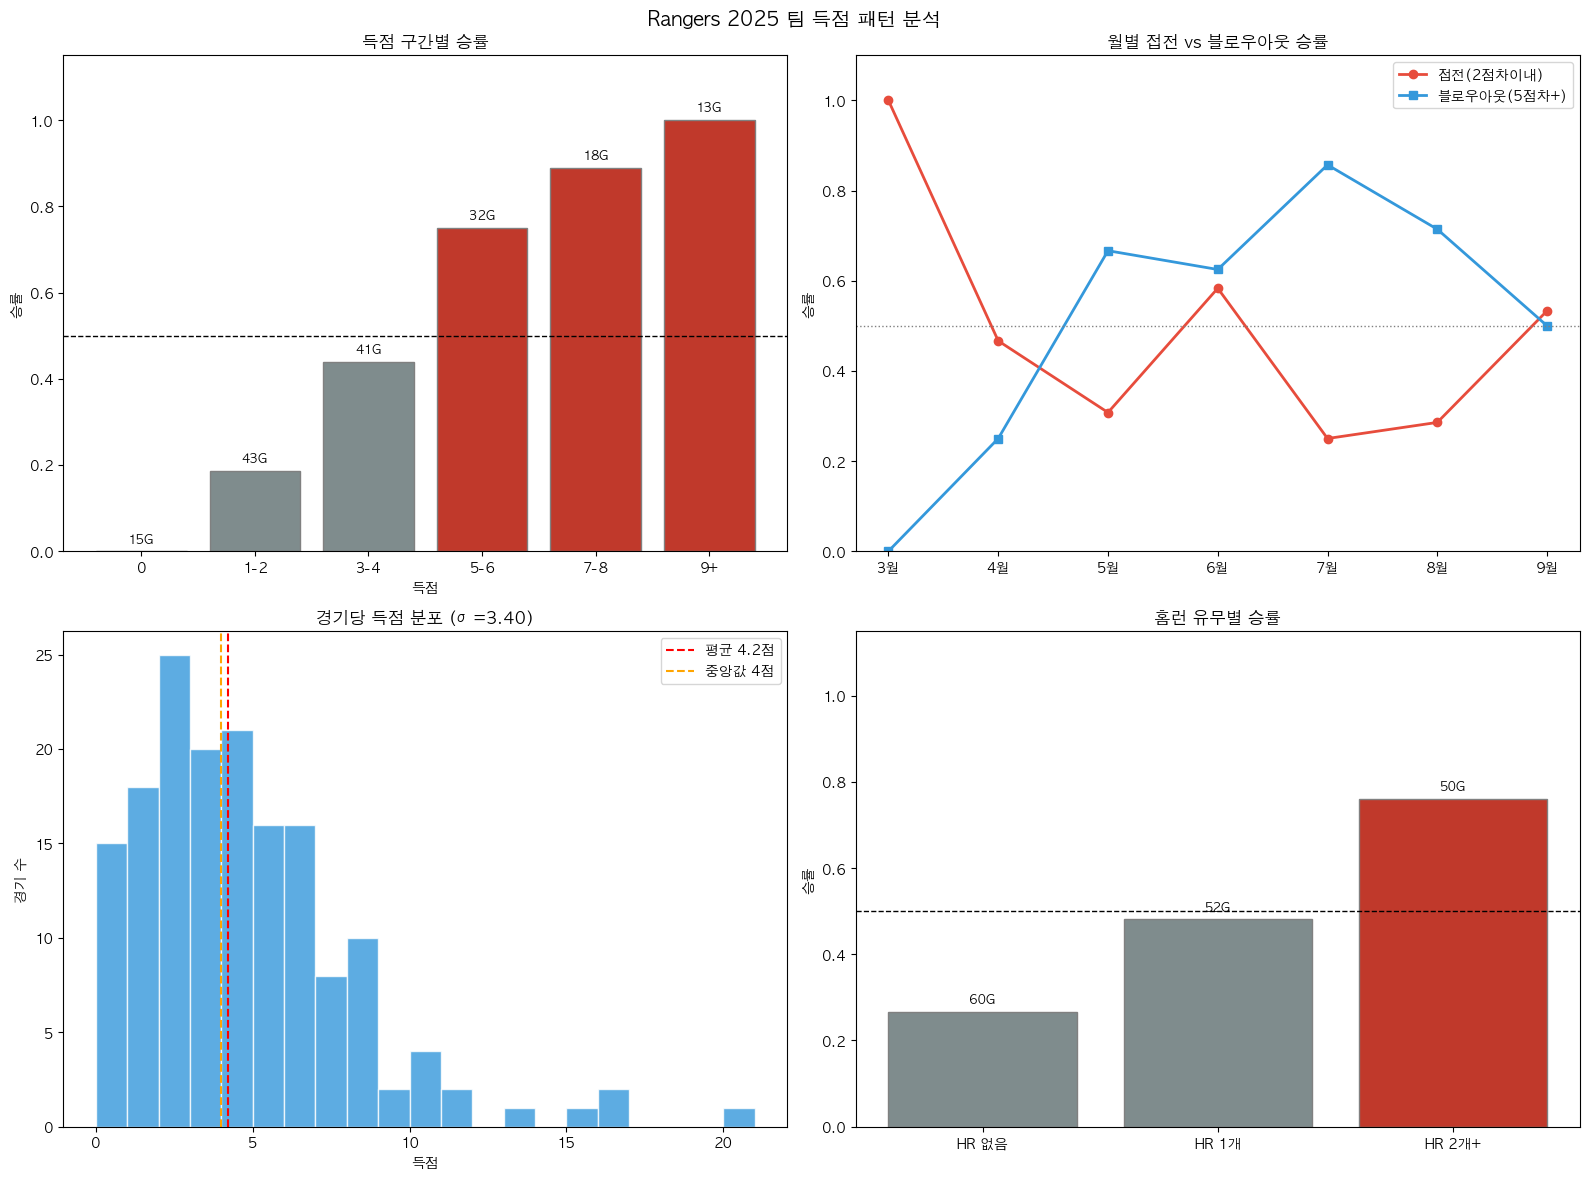

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- 좌상: 득점 구간별 승률
ax = axes[0][0]
wr_vals = score_wr["승률"].values
r_labels = score_wr.index.tolist()
colors = ["#c0392b" if v >= 0.5 else "#7f8c8d" for v in wr_vals]
bars = ax.bar(r_labels, wr_vals, color=colors, edgecolor="grey")
ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
for bar, cnt in zip(bars, score_wr["경기수"].values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f"{cnt}G", ha="center", fontsize=9)
ax.set_title("득점 구간별 승률", fontsize=12)
ax.set_xlabel("득점")
ax.set_ylabel("승률")
ax.set_ylim(0, 1.15)

# --- 우상: 접전 vs 블로우아웃 월별 승률
ax = axes[0][1]
months = sorted(games["month"].unique())
close_wr = [games[(games["month"]==m) & games["close"]]["win"].mean() for m in months]
blow_wr  = [games[(games["month"]==m) & (games["score_diff"].abs()>=5)]["win"].mean() for m in months]
x = range(len(months))
ax.plot(x, close_wr, "o-", color="#e74c3c", label="접전(2점차이내)", linewidth=2)
ax.plot(x, blow_wr,  "s-", color="#3498db", label="블로우아웃(5점차+)", linewidth=2)
ax.axhline(0.5, color="grey", linestyle=":", linewidth=1)
ax.set_xticks(list(x))
ax.set_xticklabels([f"{m}월" for m in months])
ax.set_title("월별 접전 vs 블로우아웃 승률", fontsize=12)
ax.set_ylabel("승률")
ax.set_ylim(0, 1.1)
ax.legend()

# --- 좌하: 득점 분포 히스토그램
ax = axes[1][0]
ax.hist(games["R"], bins=range(0, 22), color="#3498db", edgecolor="white", alpha=0.8)
ax.axvline(games["R"].mean(), color="red", linestyle="--", linewidth=1.5, label=f"평균 {games['R'].mean():.1f}점")
ax.axvline(games["R"].median(), color="orange", linestyle="--", linewidth=1.5, label=f"중앙값 {games['R'].median():.0f}점")
ax.set_title(f"경기당 득점 분포 (σ={games['R'].std():.2f})", fontsize=12)
ax.set_xlabel("득점")
ax.set_ylabel("경기 수")
ax.legend()

# --- 우하: HR 유무별 승률
ax = axes[1][1]
hr_cats = ["HR 없음", "HR 1개", "HR 2개+"]
hr_wrs  = [
    games[games["HR"]==0]["win"].mean(),
    games[games["HR"]==1]["win"].mean(),
    games[games["HR"]>=2]["win"].mean(),
]
hr_cnts = [
    (games["HR"]==0).sum(),
    (games["HR"]==1).sum(),
    (games["HR"]>=2).sum(),
]
colors_hr = ["#c0392b" if v>=0.5 else "#7f8c8d" for v in hr_wrs]
bars = ax.bar(hr_cats, hr_wrs, color=colors_hr, edgecolor="grey")
for bar, cnt in zip(bars, hr_cnts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f"{cnt}G", ha="center", fontsize=9)
ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
ax.set_title("홈런 유무별 승률", fontsize=12)
ax.set_ylabel("승률")
ax.set_ylim(0, 1.15)

plt.suptitle("Rangers 2025 팀 득점 패턴 분석", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 클러치 지표 분석 (WPA / RE24 / Clutch)

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

bat = pd.read_csv("./data/tex_clutch_bat.csv")
pit = pd.read_csv("./data/tex_clutch_pit.csv")

# 인코딩 수정
bat["Name"] = bat["Name"].str.replace("GarcÃ­a", "García", regex=False)

# 반올림
for col in ["WPA", "+WPA", "-WPA", "RE24", "pLI", "WPA/LI", "Clutch"]:
    if col in bat.columns: bat[col] = bat[col].round(3)
for col in ["WPA", "RE24", "pLI", "inLI", "gmLI", "WPA/LI", "Clutch"]:
    if col in pit.columns: pit[col] = pit[col].round(3)

print("=== 타자 클러치 (Clutch 내림차순) ===")
display(bat[["Name","WPA","RE24","pLI","WPA/LI","Clutch"]].sort_values("Clutch", ascending=False))
print()
print("=== 투수 클러치 (Clutch 내림차순) ===")
display(pit[["Name","WPA","RE24","pLI","gmLI","WPA/LI","Clutch"]].sort_values("Clutch", ascending=False))


=== 타자 클러치 (Clutch 내림차순) ===


,Name,WPA,RE24,pLI,WPA/LI,Clutch
0,Kyle Higashioka,0.197,2.787,1.013,-0.506,0.701
1,Rowdy Tellez,0.883,0.515,1.209,0.141,0.589
2,Alejandro Osuna,-0.122,-2.867,0.983,-0.690,0.566
3,Wyatt Langford,1.302,12.098,0.978,0.876,0.456
4,Marcus Semien,-0.284,-4.221,1.030,-0.703,0.427
5,Michael Helman,0.380,7.300,0.973,0.145,0.246
6,Jonah Heim,-0.878,-8.287,0.977,-1.123,0.224
7,Cody Freeman,-0.679,-2.825,1.126,-0.758,0.155
8,Ezequiel Duran,-1.033,-11.879,0.979,-1.165,0.109
9,Dustin Harris,-0.261,-2.678,1.049,-0.251,0.002



=== 투수 클러치 (Clutch 내림차순) ===


,Name,WPA,RE24,pLI,gmLI,WPA/LI,Clutch
5,Jacob Latz,1.712,10.680,0.863,1.074,0.982,1.003
3,Shawn Armstrong,2.776,17.975,1.242,1.317,1.368,0.867
0,Nathan Eovaldi,3.883,33.544,0.968,0.875,3.363,0.648
4,Cole Winn,1.280,16.367,0.904,0.841,0.896,0.519
2,Tyler Mahle,2.297,21.476,1.039,0.877,1.782,0.428
12,Merrill Kelly,0.118,-1.997,0.951,0.875,-0.297,0.421
14,Kumar Rocker,-0.924,-9.980,1.050,0.878,-1.174,0.293
1,Jacob deGrom,2.546,28.073,0.900,0.863,2.852,-0.022
6,Jack Leiter,0.350,9.008,1.049,0.871,0.465,-0.130
15,Caleb Boushley,-0.346,-10.515,0.303,0.404,-0.963,-0.178


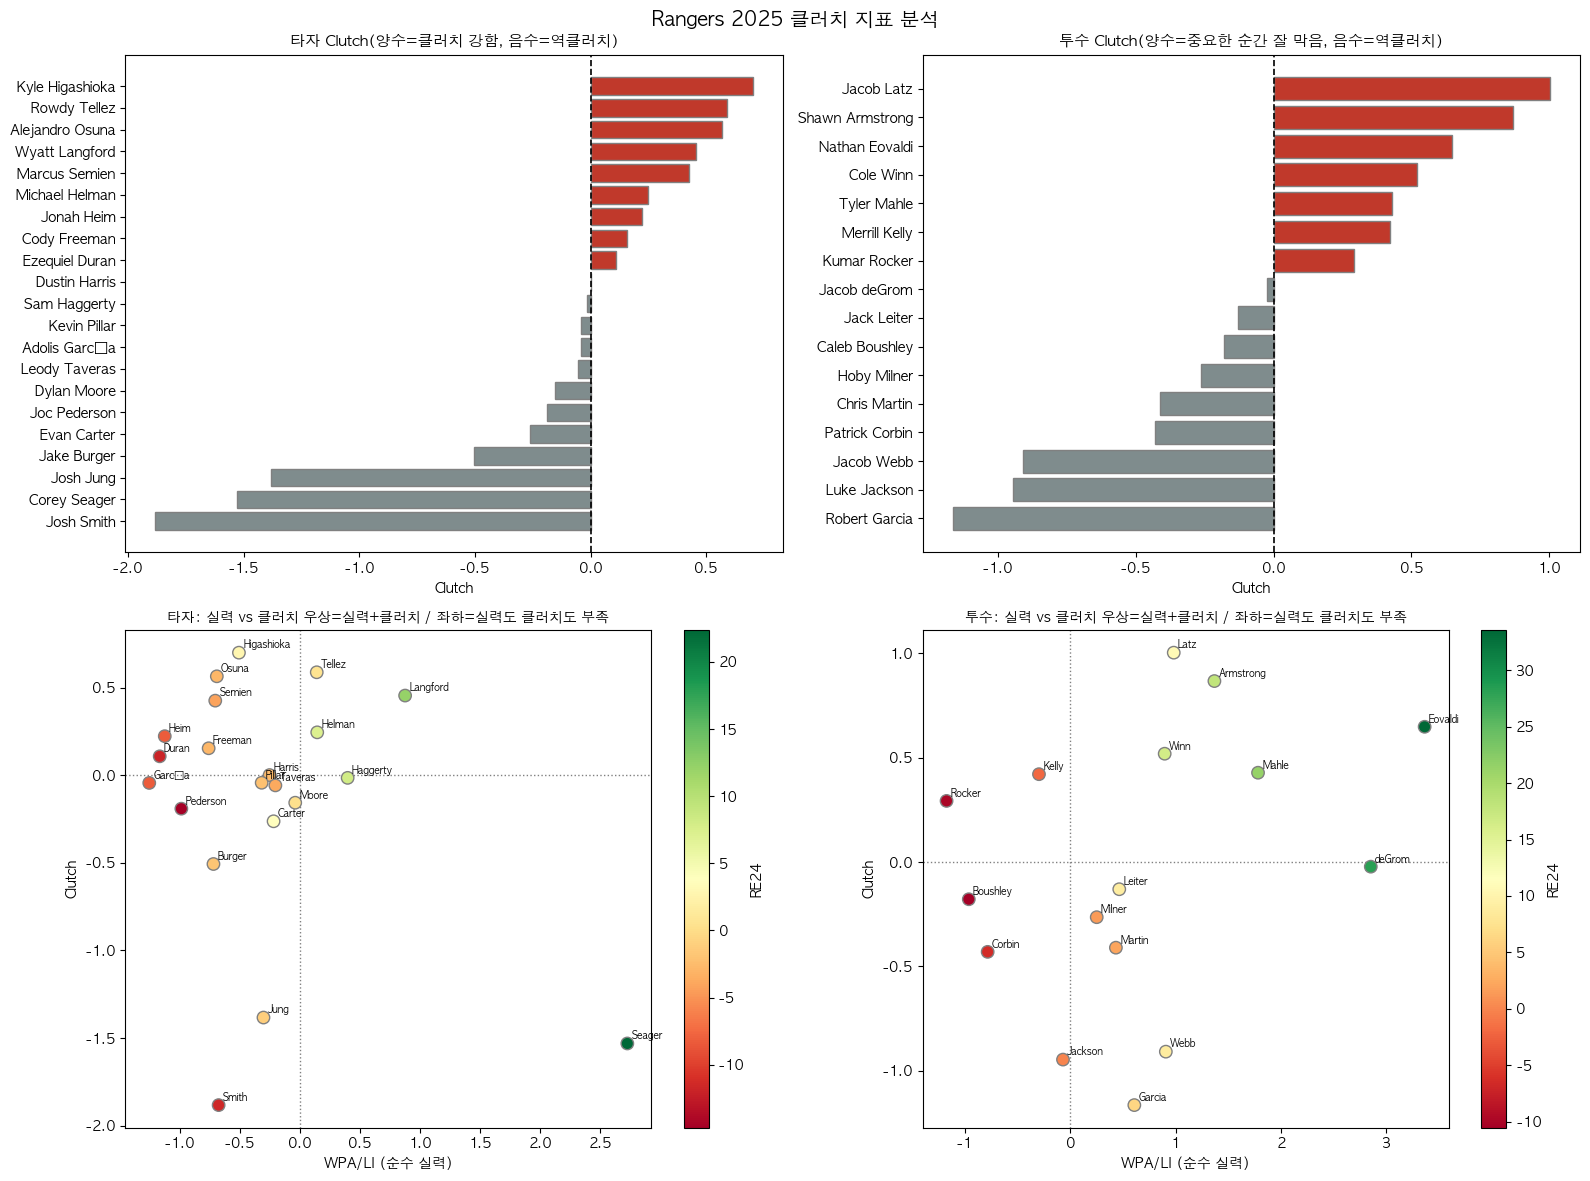

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- 좌상: 타자 Clutch 바차트
ax = axes[0][0]
df = bat[["Name","Clutch"]].sort_values("Clutch", ascending=True)
colors = ["#c0392b" if v >= 0 else "#7f8c8d" for v in df["Clutch"]]
ax.barh(df["Name"], df["Clutch"], color=colors, edgecolor="grey")
ax.axvline(0, color="black", linewidth=1.2, linestyle="--")
ax.set_title("타자 Clutch(양수=클러치 강함, 음수=역클러치)", fontsize=11)
ax.set_xlabel("Clutch")

# --- 우상: 투수 Clutch 바차트
ax = axes[0][1]
df = pit[["Name","Clutch"]].sort_values("Clutch", ascending=True)
colors = ["#c0392b" if v >= 0 else "#7f8c8d" for v in df["Clutch"]]
ax.barh(df["Name"], df["Clutch"], color=colors, edgecolor="grey")
ax.axvline(0, color="black", linewidth=1.2, linestyle="--")
ax.set_title("투수 Clutch(양수=중요한 순간 잘 막음, 음수=역클러치)", fontsize=11)
ax.set_xlabel("Clutch")

# --- 좌하: 타자 WPA/LI vs Clutch (실력 vs 클러치)
ax = axes[1][0]
sc = ax.scatter(bat["WPA/LI"], bat["Clutch"], s=80, edgecolors="grey",
                c=bat["RE24"], cmap="RdYlGn", zorder=3)
plt.colorbar(sc, ax=ax, label="RE24")
ax.axvline(0, color="grey", linestyle=":", linewidth=1)
ax.axhline(0, color="grey", linestyle=":", linewidth=1)
for _, row in bat.iterrows():
    ax.annotate(row["Name"].split()[-1], (row["WPA/LI"], row["Clutch"]),
                fontsize=7, xytext=(3,3), textcoords="offset points")
ax.set_xlabel("WPA/LI (순수 실력)")
ax.set_ylabel("Clutch")
ax.set_title("타자: 실력 vs 클러치 우상=실력+클러치 / 좌하=실력도 클러치도 부족", fontsize=10)

# --- 우하: 투수 WPA/LI vs Clutch
ax = axes[1][1]
sc = ax.scatter(pit["WPA/LI"], pit["Clutch"], s=80, edgecolors="grey",
                c=pit["RE24"], cmap="RdYlGn", zorder=3)
plt.colorbar(sc, ax=ax, label="RE24")
ax.axvline(0, color="grey", linestyle=":", linewidth=1)
ax.axhline(0, color="grey", linestyle=":", linewidth=1)
for _, row in pit.iterrows():
    ax.annotate(row["Name"].split()[-1], (row["WPA/LI"], row["Clutch"]),
                fontsize=7, xytext=(3,3), textcoords="offset points")
ax.set_xlabel("WPA/LI (순수 실력)")
ax.set_ylabel("Clutch")
ax.set_title("투수: 실력 vs 클러치 우상=실력+클러치 / 좌하=실력도 클러치도 부족", fontsize=10)

plt.suptitle("Rangers 2025 클러치 지표 분석", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 부상 전후 선수 퍼포먼스 변화

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

batter_gl  = pd.read_csv("./data/rangers_batter_gamelogs.csv")
pitcher_gl = pd.read_csv("./data/rangers_pitcher_gamelogs.csv")
batter_gl["Date"]  = pd.to_datetime(batter_gl["Date"])
pitcher_gl["Date"] = pd.to_datetime(pitcher_gl["Date"])

# 부상 타임라인
injury_info = {
    "Evan Carter": [
        ("허벅지(결장)",  "2025-05-16", "2025-06-03"),
        ("손목골절(시즌끝)","2025-08-21", "2025-09-28"),
    ],
    "Corey Seager": [
        ("햄스트링1",  "2025-04-22", "2025-05-03"),
        ("햄스트링2",  "2025-05-10", "2025-05-28"),
        ("수술(시즌끝)","2025-08-27", "2025-09-28"),
    ],
    "Wyatt Langford": [
        ("결장1", "2025-04-08", "2025-04-20"),
        ("결장2", "2025-06-24", "2025-07-05"),
    ],
}

def rolling_stats(df, name, window=15):
    d = df[(df["name"]==name) & (df["AB"]>0)].sort_values("Date").copy()
    d["roll_AVG"] = (d["H"].rolling(window, min_periods=5).sum() /
                     d["AB"].rolling(window, min_periods=5).sum()).round(3)
    d["roll_OBP"] = ((d["H"]+d["BB"]).rolling(window, min_periods=5).sum() /
                     (d["AB"]+d["BB"]).rolling(window, min_periods=5).sum()).round(3)
    d["roll_K%"]  = (d["SO"].rolling(window, min_periods=5).sum() /
                     d["PA"].rolling(window, min_periods=5).sum()).round(3)
    return d

print("부상 전후 구간별 성적")
windows = {
    "Evan Carter": [
        ("1차부상전", "2025-05-06", "2025-05-16"),
        ("1차복귀후", "2025-06-03", "2025-08-01"),
        ("2차부상직전","2025-08-13","2025-08-21"),
    ],
    "Corey Seager": [
        ("부상전",   "2025-03-27", "2025-04-22"),
        ("복귀후",   "2025-05-28", "2025-08-27"),
    ],
    "Wyatt Langford": [
        ("전반기",   "2025-03-27", "2025-06-24"),
        ("후반기",   "2025-07-05", "2025-09-23"),
    ],
}

for name, periods in windows.items():
    print(f"{name}")
    for label, s, e in periods:
        d = batter_gl[(batter_gl["name"]==name) &
                      (batter_gl["Date"]>=s) & (batter_gl["Date"]<=e) &
                      (batter_gl["AB"]>0)]
        if len(d) == 0: continue
        pa = d["PA"].sum(); ab = d["AB"].sum()
        avg = round(d["H"].sum()/ab, 3)
        obp = round((d["H"].sum()+d["BB"].sum())/(ab+d["BB"].sum()), 3)
        kp  = round(d["SO"].sum()/pa, 3)
        bbp = round(d["BB"].sum()/pa, 3)
        print(f"  {label}({s[:7]}~{e[:7]}): PA={pa} AVG={avg} OBP={obp} K%={kp} BB%={bbp}")


부상 전후 구간별 성적
Evan Carter
  1차부상전(2025-05~2025-05): PA=36 AVG=0.182 OBP=0.25 K%=0.167 BB%=0.083
  1차복귀후(2025-06~2025-08): PA=152 AVG=0.252 OBP=0.322 K%=0.217 BB%=0.092
  2차부상직전(2025-08~2025-08): PA=31 AVG=0.308 OBP=0.357 K%=0.065 BB%=0.065
Corey Seager
  부상전(2025-03~2025-04): PA=84 AVG=0.286 OBP=0.345 K%=0.179 BB%=0.083
  복귀후(2025-05~2025-08): PA=338 AVG=0.261 OBP=0.375 K%=0.204 BB%=0.151
Wyatt Langford
  전반기(2025-03~2025-06): PA=292 AVG=0.232 OBP=0.307 K%=0.26 BB%=0.096
  후반기(2025-07~2025-09): PA=281 AVG=0.252 OBP=0.377 K%=0.267 BB%=0.164


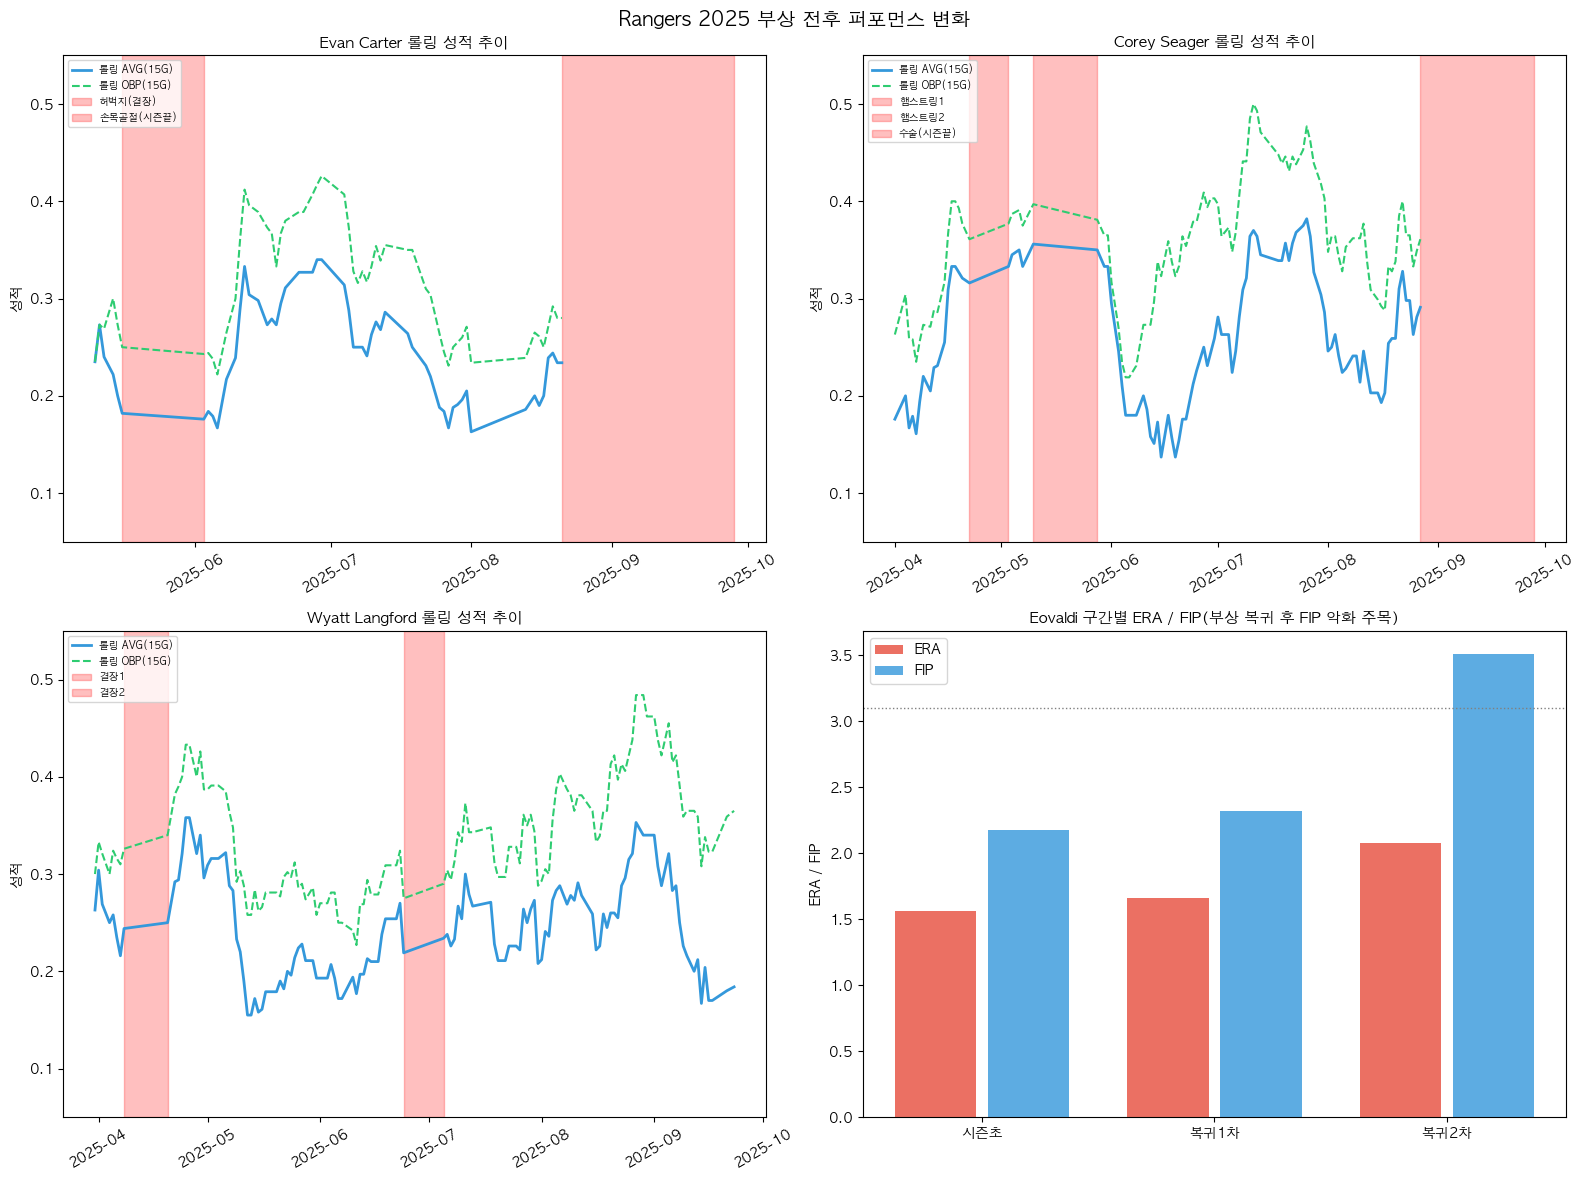

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
players = ["Evan Carter", "Corey Seager", "Wyatt Langford"]
ax_map = {"Evan Carter": axes[0][0], "Corey Seager": axes[0][1], "Wyatt Langford": axes[1][0]}

for name in players:
    ax = ax_map[name]
    d = rolling_stats(batter_gl, name)
    ax.plot(d["Date"], d["roll_AVG"], color="#3498db", linewidth=2, label="롤링 AVG(15G)")
    ax.plot(d["Date"], d["roll_OBP"], color="#2ecc71", linewidth=1.5, linestyle="--", label="롤링 OBP(15G)")
    # 부상 구간 음영
    for label, s, e in injury_info.get(name, []):
        ax.axvspan(pd.to_datetime(s), pd.to_datetime(e),
                   alpha=0.25, color="red", label=label)
    ax.set_title(f"{name} 롤링 성적 추이", fontsize=11)
    ax.set_ylabel("성적")
    ax.set_ylim(0.05, 0.55)
    ax.legend(fontsize=7, loc="upper left")
    ax.tick_params(axis="x", rotation=30)

# --- 우하: Eovaldi 구간별 ERA/FIP
ax = axes[1][1]
def calc_pit(name, s, e):
    d = pitcher_gl[(pitcher_gl["name"]==name) &
                   (pitcher_gl["Date"]>=s) & (pitcher_gl["Date"]<=e)]
    if len(d)==0: return None, None
    ip = d["IP"].apply(lambda x: int(x)+(x%1)/0.3).sum()
    er = d["ER"].sum(); bb=d["BB"].sum(); so=d["SO"].sum(); hr=d["HR"].sum()
    era = round(er*9/ip, 2) if ip>0 else None
    fip = round((13*hr+3*bb-2*so)/ip+3.10, 2) if ip>0 else None
    return era, fip

eov_periods = [("시즌초","2025-03-27","2025-05-27"),
               ("복귀1차","2025-06-27","2025-07-13"),
               ("복귀2차","2025-07-25","2025-08-22")]
labels_e = [p[0] for p in eov_periods]
eras = []; fips = []
for label, s, e in eov_periods:
    era, fip = calc_pit("Nathan Eovaldi", s, e)
    eras.append(era); fips.append(fip)
x = range(len(labels_e))
ax.bar([i-0.2 for i in x], eras, 0.35, label="ERA", color="#e74c3c", alpha=0.8)
ax.bar([i+0.2 for i in x], fips, 0.35, label="FIP", color="#3498db", alpha=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(labels_e)
ax.set_title("Eovaldi 구간별 ERA / FIP(부상 복귀 후 FIP 악화 주목)", fontsize=11)
ax.set_ylabel("ERA / FIP")
ax.legend()
ax.axhline(3.10, color="grey", linestyle=":", linewidth=1, label="FIP 기준(3.10)")

plt.suptitle("Rangers 2025 부상 전후 퍼포먼스 변화", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 시점별 팀 성적 변화 (부상 타임라인 연동)

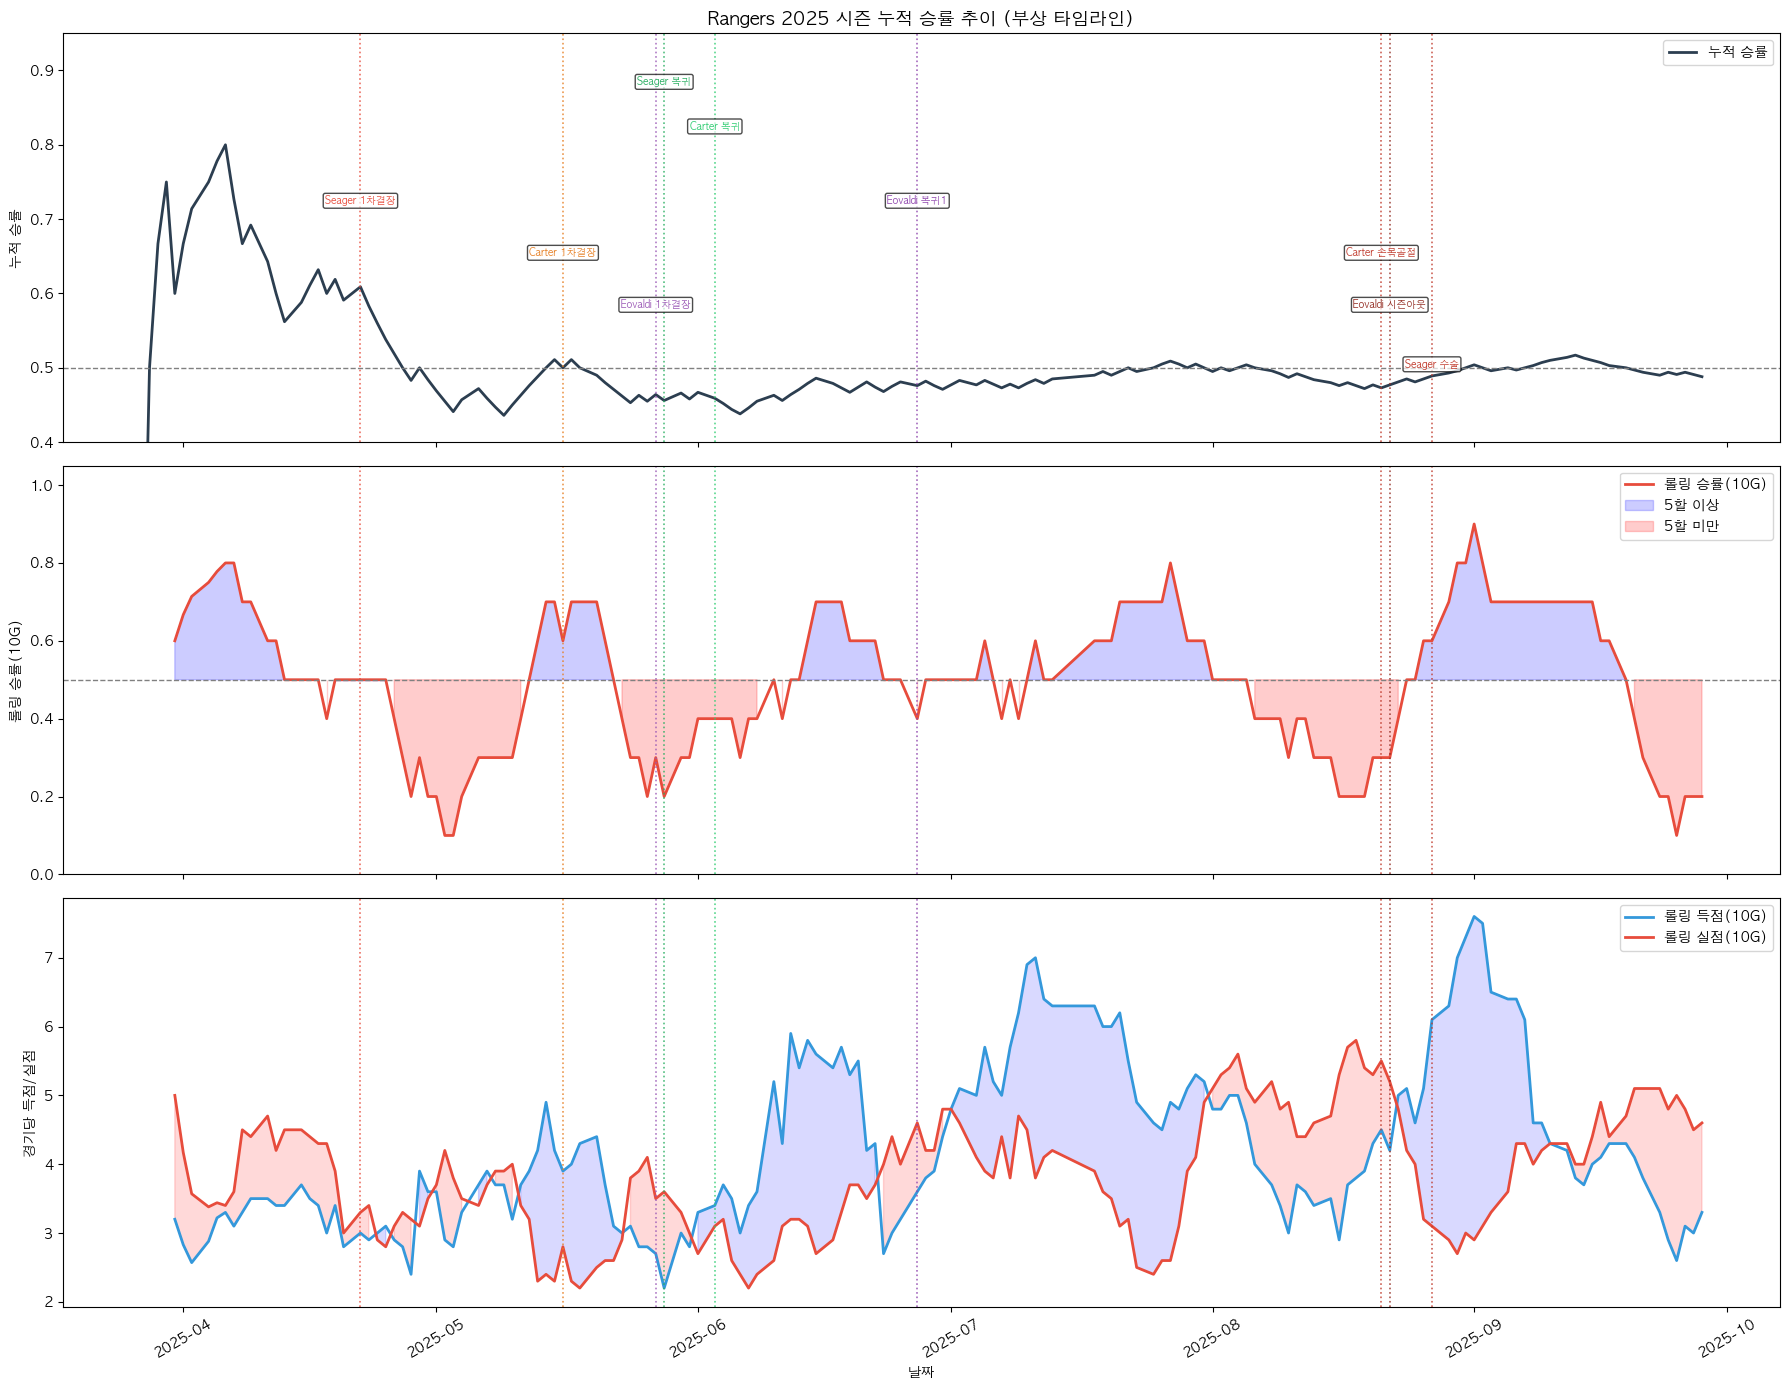

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

batter_gl  = pd.read_csv("./data/rangers_batter_gamelogs.csv")
pitcher_gl = pd.read_csv("./data/rangers_pitcher_gamelogs.csv")
batter_gl["Date"]  = pd.to_datetime(batter_gl["Date"])
pitcher_gl["Date"] = pd.to_datetime(pitcher_gl["Date"])

bat_game = batter_gl.groupby("Date").agg(
    R=("R","sum"), HR=("HR","sum"), BB=("BB","sum"), SO=("SO","sum")
).reset_index()
pit_game = pitcher_gl.groupby("Date").agg(R_allowed=("R","sum")).reset_index()
games = bat_game.merge(pit_game, on="Date").sort_values("Date").reset_index(drop=True)
games["win"]     = (games["R"] > games["R_allowed"]).astype(int)
games["cum_W"]   = games["win"].cumsum()
games["cum_G"]   = range(1, len(games)+1)
games["win_pct"] = (games["cum_W"] / games["cum_G"]).round(3)

# 10경기 롤링 승률
games["roll_wr"]  = games["win"].rolling(10, min_periods=5).mean().round(3)
games["roll_R"]   = games["R"].rolling(10, min_periods=5).mean().round(2)
games["roll_RA"]  = games["R_allowed"].rolling(10, min_periods=5).mean().round(2)

# 부상 이벤트
events = [
    ("2025-04-22", "Seager 1차결장",  "#e74c3c",  0.72),
    ("2025-05-16", "Carter 1차결장",  "#e67e22",  0.65),
    ("2025-05-27", "Eovaldi 1차결장", "#9b59b6",  0.58),
    ("2025-05-28", "Seager 복귀",     "#27ae60",  0.88),
    ("2025-06-03", "Carter 복귀",     "#2ecc71",  0.82),
    ("2025-06-27", "Eovaldi 복귀1",  "#8e44ad",  0.72),
    ("2025-08-21", "Carter 손목골절", "#c0392b",  0.65),
    ("2025-08-22", "Eovaldi 시즌아웃","#922b21",  0.58),
    ("2025-08-27", "Seager 수술",     "#c0392b",  0.50),
]

fig, axes = plt.subplots(3, 1, figsize=(18, 14), sharex=True)

# --- 상단: 누적 승률
ax = axes[0]
ax.plot(games["Date"], games["win_pct"], color="#2c3e50", linewidth=2, label="누적 승률")
ax.axhline(0.5, color="grey", linestyle="--", linewidth=1)
for date_str, label, color, y in events:
    d = pd.to_datetime(date_str)
    ax.axvline(d, color=color, linestyle=":", linewidth=1.2, alpha=0.8)
    ax.text(d, y, label, fontsize=7, color=color, ha="center",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))
ax.set_ylabel("누적 승률")
ax.set_title("Rangers 2025 시즌 누적 승률 추이 (부상 타임라인)", fontsize=13)
ax.set_ylim(0.40, 0.95)
ax.legend()

# --- 중단: 롤링 10경기 승률
ax = axes[1]
ax.plot(games["Date"], games["roll_wr"], color="#e74c3c", linewidth=2, label="롤링 승률(10G)")
ax.axhline(0.5, color="grey", linestyle="--", linewidth=1)
ax.fill_between(games["Date"], games["roll_wr"], 0.5,
                where=games["roll_wr"]>=0.5, alpha=0.2, color="blue", label="5할 이상")
ax.fill_between(games["Date"], games["roll_wr"], 0.5,
                where=games["roll_wr"]<0.5,  alpha=0.2, color="red",  label="5할 미만")
for date_str, label, color, y in events:
    ax.axvline(pd.to_datetime(date_str), color=color, linestyle=":", linewidth=1.2, alpha=0.8)
ax.set_ylabel("롤링 승률(10G)")
ax.set_ylim(0, 1.05)
ax.legend()

# --- 하단: 롤링 득점 vs 실점
ax = axes[2]
ax.plot(games["Date"], games["roll_R"],  color="#3498db", linewidth=2, label="롤링 득점(10G)")
ax.plot(games["Date"], games["roll_RA"], color="#e74c3c", linewidth=2, label="롤링 실점(10G)")
ax.fill_between(games["Date"], games["roll_R"], games["roll_RA"],
                where=games["roll_R"]>=games["roll_RA"], alpha=0.15, color="blue")
ax.fill_between(games["Date"], games["roll_R"], games["roll_RA"],
                where=games["roll_R"]<games["roll_RA"],  alpha=0.15, color="red")
for date_str, label, color, y in events:
    ax.axvline(pd.to_datetime(date_str), color=color, linestyle=":", linewidth=1.2, alpha=0.8)
ax.set_ylabel("경기당 득점/실점")
ax.set_xlabel("날짜")
ax.legend()
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


In [45]:
# 부상 시점 기준 구간별 팀 성적
periods = [
    ("시즌초(건강)",        "2025-03-27", "2025-04-21"),
    ("Seager결장",          "2025-04-22", "2025-05-27"),
    ("Seager+Carter결장",   "2025-05-16", "2025-05-27"),
    ("전원복귀(최전성기)",   "2025-06-03", "2025-08-20"),
    ("연쇄부상(붕괴기)",     "2025-08-21", "2025-09-28"),
]

rows = []
for label, s, e in periods:
    d = games[(games["Date"]>=s) & (games["Date"]<=e)]
    g = len(d); w = d["win"].sum(); l = g - w
    rs = d["R"].sum(); ra = d["R_allowed"].sum()
    rows.append({
        "구간": label, "G":g, "W":w, "L":l,
        "승률": round(w/g,3) if g>0 else None,
        "RS/G": round(rs/g,2), "RA/G": round(ra/g,2),
        "득실차": rs-ra
    })

summary = pd.DataFrame(rows)
display(summary)


,구간,G,W,L,승률,RS/G,RA/G,득실차
0,시즌초(건강),22,13,9,0.591,3.05,3.68,-14
1,Seager결장,34,13,21,0.382,3.47,3.35,4
2,Seager+Carter결장,11,3,8,0.273,2.73,3.73,-11
3,전원복귀(최전성기),68,33,35,0.485,4.69,4.19,34
4,연쇄부상(붕괴기),34,18,16,0.529,4.74,4.12,21


## 접전 경기 대응 분석 

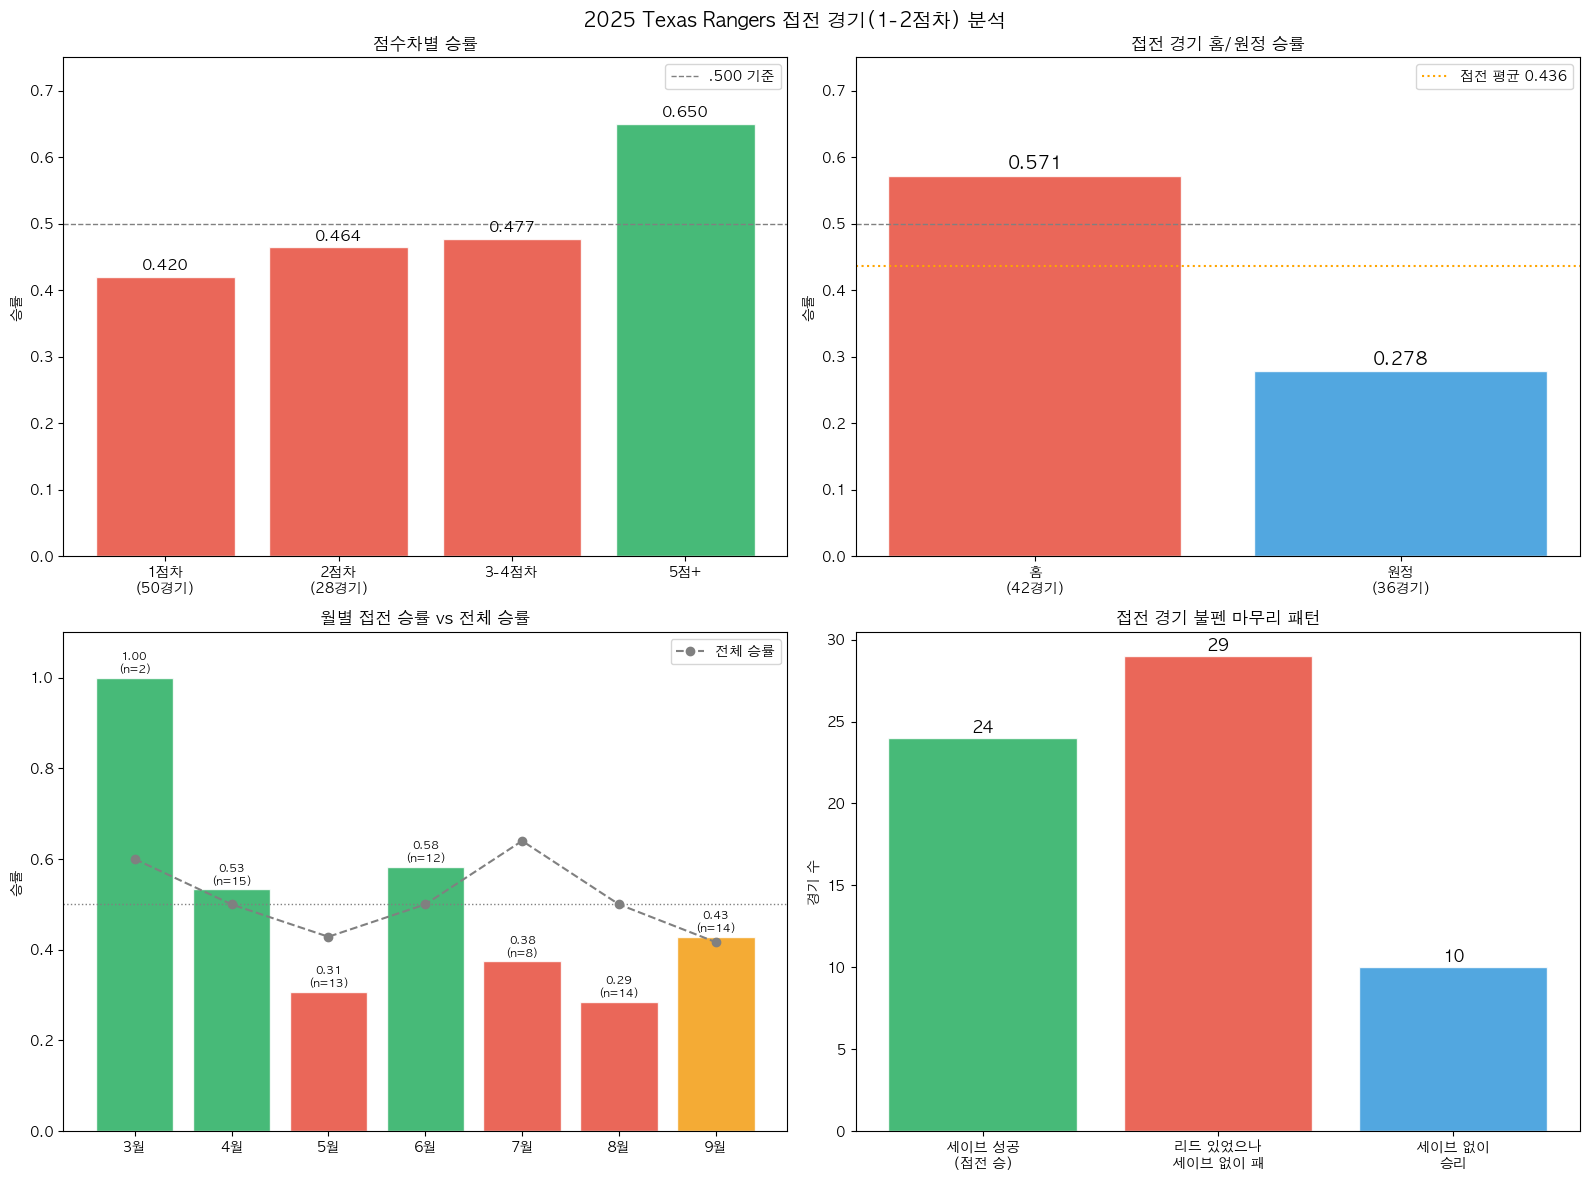

=== 접전 경기 핵심 요약 ===
전체 접전 경기: 78경기 (시즌의 48.1%)
접전 승률: 0.436 (홈 0.571 / 원정 0.278)
접전 홈-원정 승률 차: 0.294
5월 접전 승률: 0.308
8월 접전 승률: 0.286


In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import platform

if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('./data/texas_2025_game_log.csv')
df['is_home'] = df['Home_Away'] == 'Home'
df['win'] = df['W/L'].str.startswith('W')
df['run_diff'] = df['R'] - df['RA']
df['abs_diff'] = df['run_diff'].abs()
df['Date_parsed'] = pd.to_datetime(df['Date'].str.extract(r',\s*(\w+ \d+)')[0] + ' 2025',
                                    format='%b %d %Y', errors='coerce')
df['month'] = df['Date_parsed'].dt.month

close   = df[df['abs_diff'] <= 2].copy()
blowout = df[df['abs_diff'] >= 5].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('2025 Texas Rangers 접전 경기(1-2점차) 분석', fontsize=14, fontweight='bold')

# --- 1) 경기 유형별 승률 ---
ax1 = axes[0][0]
type_labels = ['1점차\n(50경기)', '2점차\n(28경기)', '3-4점차', '5점+']
type_wins = [
    df[df['abs_diff']==1]['win'].mean(),
    df[df['abs_diff']==2]['win'].mean(),
    df[(df['abs_diff']>=3)&(df['abs_diff']<=4)]['win'].mean(),
    blowout['win'].mean()
]
colors = ['#E74C3C' if v < 0.5 else '#27AE60' for v in type_wins]
bars = ax1.bar(type_labels, type_wins, color=colors, edgecolor='white', alpha=0.85)
ax1.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='.500 기준')
for bar, val in zip(bars, type_wins):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
ax1.set_ylabel('승률')
ax1.set_title('점수차별 승률')
ax1.set_ylim(0, 0.75)
ax1.legend()

# --- 2) 접전 경기 홈/원정 승률 ---
ax2 = axes[0][1]
hw = close[close['is_home']]['win'].mean()
aw = close[~close['is_home']]['win'].mean()
hc = len(close[close['is_home']])
ac = len(close[~close['is_home']])
bars2 = ax2.bar([f'홈\n({hc}경기)', f'원정\n({ac}경기)'],
                [hw, aw], color=['#E74C3C', '#3498DB'], edgecolor='white', alpha=0.85)
ax2.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax2.axhline(close['win'].mean(), color='orange', linestyle=':', linewidth=1.5,
            label=f'접전 평균 {close["win"].mean():.3f}')
for bar, val in zip(bars2, [hw, aw]):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{val:.3f}', ha='center', fontsize=13, fontweight='bold')
ax2.set_ylabel('승률')
ax2.set_title('접전 경기 홈/원정 승률')
ax2.set_ylim(0, 0.75)
ax2.legend()

# --- 3) 월별 접전 승률 ---
ax3 = axes[1][0]
month_close = close.groupby('month')['win'].agg(['mean','count']).reset_index()
month_all   = df.groupby('month')['win'].mean().reset_index()
month_labels = {3:'3월',4:'4월',5:'5월',6:'6월',7:'7월',8:'8월',9:'9월'}
month_close['label'] = month_close['month'].map(month_labels)
month_all['label']   = month_all['month'].map(month_labels)
x3 = np.arange(len(month_close))
bar_colors = ['#E74C3C' if v < 0.4 else '#F39C12' if v < 0.5 else '#27AE60'
              for v in month_close['mean']]
bars3 = ax3.bar(x3, month_close['mean'], color=bar_colors, edgecolor='white', alpha=0.85)
ax3.plot(x3, month_all['win'].values[:len(x3)], 'o--', color='gray',
         linewidth=1.5, label='전체 승률', markersize=6)
ax3.axhline(0.5, color='gray', linestyle=':', linewidth=1)
for bar, val, cnt in zip(bars3, month_close['mean'], month_close['count']):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{val:.2f}\n(n={cnt})', ha='center', fontsize=8)
ax3.set_xticks(x3)
ax3.set_xticklabels(month_close['label'])
ax3.set_ylabel('승률')
ax3.set_title('월별 접전 승률 vs 전체 승률')
ax3.set_ylim(0, 1.1)
ax3.legend()

# --- 4) 세이브/블론세이브 ---
ax4 = axes[1][1]
close['has_save'] = close['Save'].notna()
close['has_loss_pitcher'] = close['Loss'].notna()
sv_win  = close[close['has_save'] & close['win']]['win'].count()
sv_blow = close[close['has_save'] & ~close['win']]['win'].count()
no_sv_win = close[~close['has_save'] & close['win']]['win'].count()
categories = ['세이브 성공\n(접전 승)', '리드 있었으나\n세이브 없이 패', '세이브 없이\n승리']
values = [sv_win, sv_blow, no_sv_win]
colors4 = ['#27AE60', '#E74C3C', '#3498DB']
bars4 = ax4.bar(categories, values, color=colors4, edgecolor='white', alpha=0.85)
for bar, val in zip(bars4, values):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             str(val), ha='center', fontsize=12, fontweight='bold')
ax4.set_ylabel('경기 수')
ax4.set_title('접전 경기 불펜 마무리 패턴')

plt.tight_layout()
plt.show()

print('=== 접전 경기 핵심 요약 ===')
print(f'전체 접전 경기: {len(close)}경기 (시즌의 {len(close)/len(df)*100:.1f}%)')
print(f'접전 승률: {close["win"].mean():.3f} (홈 {hw:.3f} / 원정 {aw:.3f})')
print(f'접전 홈-원정 승률 차: {hw-aw:.3f}')
print(f'5월 접전 승률: {month_close[month_close["month"]==5]["mean"].values[0]:.3f}')
print(f'8월 접전 승률: {month_close[month_close["month"]==8]["mean"].values[0]:.3f}')


## 타선 WRC+ 부진 선수 분석 

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

hit_stat = pd.read_csv("./data/rangers_hitting_statcast.csv")
hit_bat  = pd.read_csv("./data/rangers_hitting_batted.csv")
hit_dis  = pd.read_csv("./data/rangers_hitting_discipline.csv")
tex_wrc  = pd.read_csv("./data/tex_wrc+.csv")
tex_wrc["wRC+"] = tex_wrc["wRC+"].round(1)

batter = hit_stat[["Player","PA","BA","OBP","SLG","wOBA","xwOBA",
                    "Barrel %","Hard Hit %","Exit Velocity","Launch Angle"]].copy()
batter = batter.merge(hit_dis[["Player","Zone %","Chase %","Whiff %",
                               "Zone Contact %","Chase Contact %","Swing %"]], on="Player")
batter = batter.merge(hit_bat[["Player","GB %","FB %","LD %","Pull %","Oppo %"]], on="Player")
batter = batter.merge(tex_wrc[["Name","wRC+"]].rename(columns={"Name":"Player"}), on="Player", how="left")
batter["ISO"]  = (batter["SLG"] - batter["BA"]).round(3)
batter["luck"] = (batter["wOBA"] - batter["xwOBA"]).round(3)

# 부진 원인 분류
def diagnose(row):
    reasons = []
    if row["Chase %"] > 28.2:         reasons.append("체이스↑")
    if row["Whiff %"] > 25.3:          reasons.append("Whiff↑")
    if row["Zone Contact %"] < 82.7:   reasons.append("존컨택↓")
    if row["Barrel %"] < 8.6:          reasons.append("Barrel↓")
    if row["Hard Hit %"] < 40.9:       reasons.append("HardHit↓")
    if row["Exit Velocity"] < 89.4:    reasons.append("EV↓")
    if row["GB %"] > 42.4:             reasons.append("GB과다")
    if row["LD %"] < 23.9:             reasons.append("LD부족")
    if row["luck"] < -0.03:          reasons.append("불운")
    return ", ".join(reasons) if reasons else "복합"

low = batter[batter["wRC+"] < 100].sort_values("wRC+").copy()
low["부진원인"] = low.apply(diagnose, axis=1)

print("=== wRC+ 100 미만 선수 부진 원인 ===")
display(low[["Player","PA","wRC+","Chase %","Whiff %","Barrel %","Hard Hit %","Exit Velocity","luck","부진원인"]]
      .rename(columns={"Exit Velocity":"EV"}))


=== wRC+ 100 미만 선수 부진 원인 ===


,Player,PA,wRC+,Chase %,Whiff %,Barrel %,Hard Hit %,EV,luck,부진원인
1,Donovan Solano,179,-100.0,36.3,26.4,3.9,37.5,87.4,0.018,"체이스↑, Whiff↑, Barrel↓, HardHit↓, EV↓, GB과다"
5,Justin Foscue,9,-18.2,13.3,10.0,0.0,66.7,93.0,-0.050,"Barrel↓, LD부족, 불운"
2,Billy McKinney,21,36.5,23.1,23.8,0.0,26.3,87.0,-0.127,"Barrel↓, HardHit↓, EV↓, 불운"
9,Ezequiel Duran,219,57.2,37.4,24.4,2.6,30.9,85.3,0.002,"체이스↑, Barrel↓, HardHit↓, EV↓"
20,Cody Freeman,121,65.9,34.8,13.6,4.1,25.8,84.9,-0.008,"체이스↑, Barrel↓, HardHit↓, EV↓, GB과다, LD부족"
11,Dustin Harris,43,68.5,32.2,24.5,3.7,25.9,86.9,0.034,"체이스↑, Barrel↓, HardHit↓, EV↓, LD부족"
10,Jonah Heim,433,69.1,30.0,24.2,6.1,35.9,88.1,-0.010,"체이스↑, 존컨택↓, Barrel↓, HardHit↓, EV↓, LD부족"
0,Alejandro Osuna,176,72.1,24.9,19.6,5.9,37.0,88.9,-0.068,"Barrel↓, HardHit↓, EV↓, GB과다, 불운"
21,Joc Pederson,306,76.3,26.9,25.2,9.5,44.8,91.2,-0.039,"LD부족, 불운"
19,Adolis García,547,82.8,35.8,30.3,11.6,46.7,92.1,-0.018,"체이스↑, Whiff↑, 존컨택↓, LD부족"


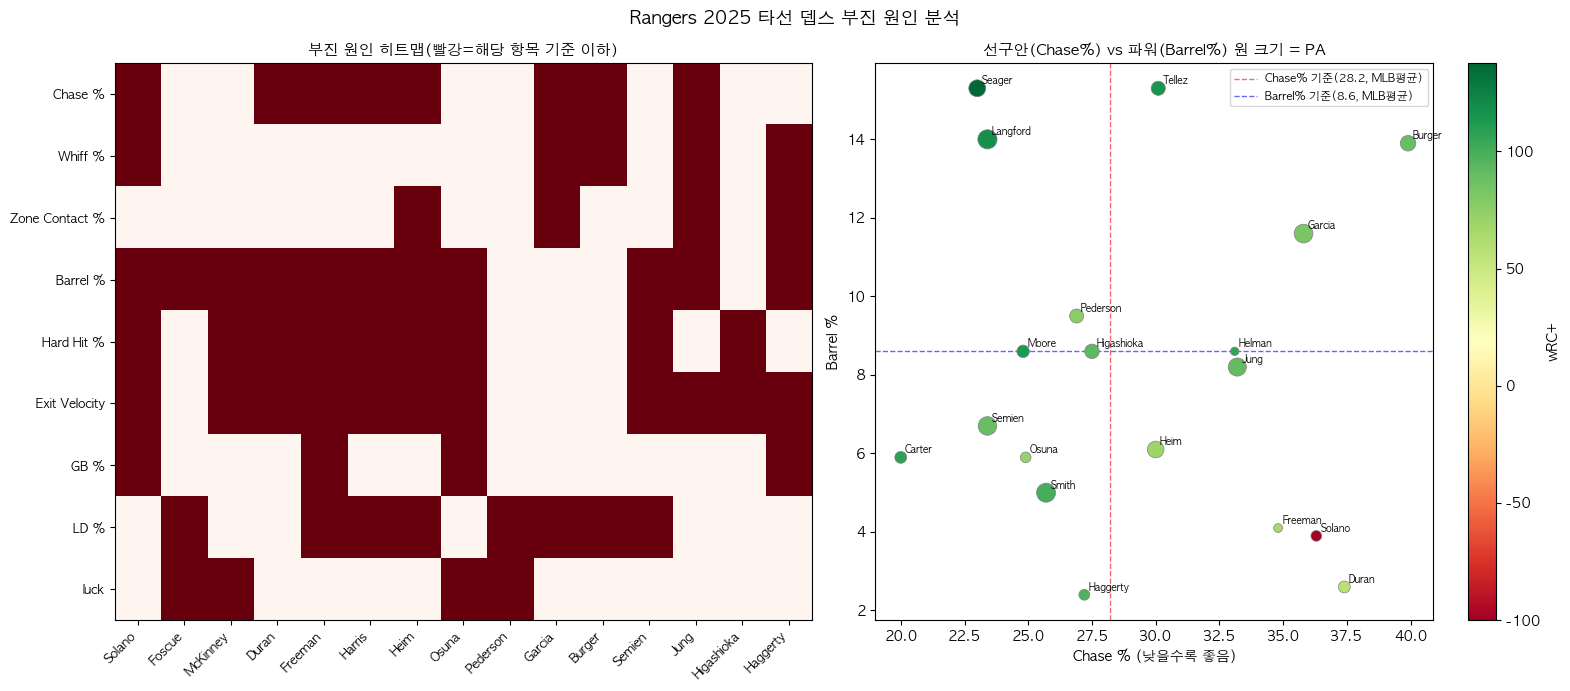

In [54]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import unicodedata

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

def to_ascii(name):
    return unicodedata.normalize('NFKD', name).encode('ascii', 'ignore').decode('ascii')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- 왼쪽: 부진 원인 히트맵
ax = axes[0]
plot_cols = ["Chase %","Whiff %","Zone Contact %","Barrel %","Hard Hit %","Exit Velocity","GB %","LD %","luck"]
thresholds = {"Chase %":28.2, "Whiff %":25.3, "Zone Contact %":82.7,
              "Barrel %":8.6, "Hard Hit %":40.9, "Exit Velocity":89.4,
              "GB %":42.4, "LD %":23.9, "luck":-0.03}
invert_cols = {"Chase %", "Whiff %", "GB %"}

low_sorted = low.set_index("Player")
heat_data = []
for col in plot_cols:
    row_vals = []
    for p in low_sorted.index:
        val = low_sorted.loc[p, col]
        thr = thresholds[col]
        if col in invert_cols:
            row_vals.append(1 if val > thr else 0)
        else:
            row_vals.append(1 if val < thr else 0)
    heat_data.append(row_vals)

heat_arr = np.array(heat_data)
ax.imshow(heat_arr, cmap="Reds", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(low_sorted.index)))
ax.set_xticklabels([to_ascii(p.split()[-1]) for p in low_sorted.index], rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(plot_cols)))
ax.set_yticklabels(plot_cols, fontsize=9)
ax.set_title("부진 원인 히트맵(빨강=해당 항목 기준 이하)", fontsize=11)

# --- 오른쪽: Chase% vs Barrel% 산점도
ax = axes[1]
df_main = batter[batter["PA"] >= 100].dropna(subset=["wRC+"])
sc = ax.scatter(df_main["Chase %"], df_main["Barrel %"],
                c=df_main["wRC+"], cmap="RdYlGn", s=df_main["PA"]/3,
                edgecolors="grey", linewidth=0.5, zorder=3)
plt.colorbar(sc, ax=ax, label="wRC+")
ax.axvline(28.2, color="red", linestyle="--", linewidth=1, alpha=0.6, label="Chase% 기준(28.2, MLB평균)")
ax.axhline(8.6, color="blue", linestyle="--", linewidth=1, alpha=0.6, label="Barrel% 기준(8.6, MLB평균)")
for _, row in df_main.iterrows():
    name = to_ascii(row["Player"].split()[-1])
    ax.annotate(name, (row["Chase %"], row["Barrel %"]),
                fontsize=7, xytext=(3,3), textcoords="offset points")
ax.set_xlabel("Chase % (낮을수록 좋음)")
ax.set_ylabel("Barrel %")
ax.set_title("선구안(Chase%) vs 파워(Barrel%) 원 크기 = PA", fontsize=11)
ax.legend(fontsize=8)

plt.suptitle("Rangers 2025 타선 뎁스 부진 원인 분석", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 주요 부진 타자 프로파일링

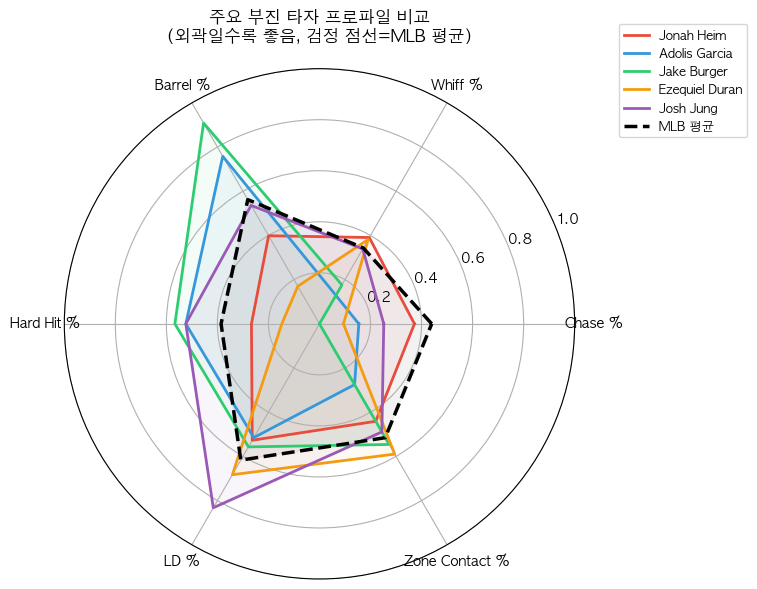

In [55]:
import matplotlib.pyplot as plt
import numpy as np
import unicodedata

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

def to_ascii(name):
    return unicodedata.normalize('NFKD', name).encode('ascii', 'ignore').decode('ascii')

targets = ["Jonah Heim", "Adolis García", "Jake Burger", "Ezequiel Duran", "Josh Jung"]
metrics = ["Chase %", "Whiff %", "Barrel %", "Hard Hit %", "LD %", "Zone Contact %"]
invert_metrics = {"Chase %", "Whiff %"}

# 리그 평균값
mlb_avg = {
    "Chase %": 28.2,
    "Whiff %": 25.3,
    "Barrel %": 8.6,
    "Hard Hit %": 40.9,
    "LD %": 23.9,
    "Zone Contact %": 82.7,
}

# 정규화 (batter 전체 기준 min/max)
df_radar = batter[batter["Player"].isin(targets)].set_index("Player")[metrics].copy()

# 리그 평균 행 추가
mlb_row = pd.Series(mlb_avg, name="MLB 평균")
df_radar = pd.concat([df_radar, mlb_row.to_frame().T])

for col in metrics:
    mn, mx = batter[col].min(), batter[col].max()
    norm = (df_radar[col] - mn) / (mx - mn)
    df_radar[col] = 1 - norm if col in invert_metrics else norm

# 레이더 차트
N = len(metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6"]
players = targets + ["MLB 평균"]
colors  = colors + ["black"]
lwidths = [2, 2, 2, 2, 2, 2.5]
lstyles = ["-", "-", "-", "-", "-", "--"]

for i, player in enumerate(players):
    if player not in df_radar.index:
        continue
    values = df_radar.loc[player, metrics].tolist()
    values += values[:1]
    ax.plot(angles, values, color=colors[i], linewidth=lwidths[i],
            linestyle=lstyles[i], label=to_ascii(player) if player != "MLB 평균" else "MLB 평균")
    ax.fill(angles, values, color=colors[i], alpha=0.05)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title("주요 부진 타자 프로파일 비교\n(외곽일수록 좋음, 검정 점선=MLB 평균)", fontsize=12, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=9)

plt.tight_layout()
plt.show()

In [56]:
# 선수 그룹별 정리
print("=" * 55)
print("[ 선구안 문제형 ] Chase% > 28.2 또는 Whiff% > 25.3")
print("=" * 55)
eye_prob = low[((low["Chase %"]>28.2) | (low["Whiff %"]>25.3)) & (low["PA"]>=40)]
print(eye_prob[["Player","wRC+","Chase %","Whiff %","Zone Contact %","BA"]].to_string(index=False))

print()
print("=" * 55)
print("[ 파워 부족형 ] Barrel% < 8.6 OR Hard Hit% < 40.9")
print("=" * 55)
pow_prob = low[((low["Barrel %"]<8.6) | (low["Hard Hit %"]<40.9)) & (low["PA"]>=40)]
print(pow_prob[["Player","wRC+","Barrel %","Hard Hit %","Exit Velocity","ISO"]].to_string(index=False))

print()
print("=" * 55)
print("[ 타구 질 문제형 ] GB% > 42.4 또는 LD% < 23.9")
print("=" * 55)
bat_prob = low[((low["GB %"]>42.4) | (low["LD %"]<23.9)) & (low["PA"]>=40)]
print(bat_prob[["Player","wRC+","GB %","FB %","LD %","Launch Angle"]].to_string(index=False))

print()
print("=" * 55)
print("[ 불운형 ] luck(wOBA-xwOBA) < -0.03")
print("=" * 55)
luck_prob = low[(low["luck"]<-0.03) & (low["PA"]>=40)]
print(luck_prob[["Player","wRC+","wOBA","xwOBA","luck","BABIP"]]
      .rename(columns={"luck":"wOBA-xwOBA"})
      .to_string(index=False) if "BABIP" in luck_prob.columns
      else luck_prob[["Player","wRC+","wOBA","xwOBA","luck"]]
      .rename(columns={"luck":"wOBA-xwOBA"}).to_string(index=False))


[ 선구안 문제형 ] Chase% > 28.2 또는 Whiff% > 25.3
        Player   wRC+  Chase %  Whiff %  Zone Contact %    BA
Donovan Solano -100.0     36.3     26.4            83.4 0.247
Ezequiel Duran   57.2     37.4     24.4            84.4 0.224
  Cody Freeman   65.9     34.8     13.6            87.8 0.228
 Dustin Harris   68.5     32.2     24.5            93.8 0.200
    Jonah Heim   69.1     30.0     24.2            81.0 0.213
 Adolis García   82.8     35.8     30.3            77.2 0.227
   Jake Burger   88.9     39.9     29.2            83.4 0.236
     Josh Jung   91.2     33.2     25.4            82.1 0.251
  Sam Haggerty   97.6     27.2     26.3            81.7 0.253

[ 파워 부족형 ] Barrel% < 8.6 OR Hard Hit% < 40.9
         Player   wRC+  Barrel %  Hard Hit %  Exit Velocity   ISO
 Donovan Solano -100.0       3.9        37.5           87.4 0.090
 Ezequiel Duran   57.2       2.6        30.9           85.3 0.069
   Cody Freeman   65.9       4.1        25.8           84.9 0.114
  Dustin Harris   68.5     

In [57]:
# 한 선수가 몇 개 유형에 걸리는지 확인
for name in low[low["PA"]>=40].sort_values("wRC+")["Player"]:
    types = []
    if name in eye_prob["Player"].values:  types.append("선구안")
    if name in pow_prob["Player"].values:  types.append("파워부족")
    if name in bat_prob["Player"].values:  types.append("타구질")
    if name in luck_prob["Player"].values: types.append("불운")
    n = len(types)
    label = f"[{n}개]" if n > 1 else "     "
    print(f"{label} {name}: {types}")


[3개] Donovan Solano: ['선구안', '파워부족', '타구질']
[2개] Ezequiel Duran: ['선구안', '파워부족']
[3개] Cody Freeman: ['선구안', '파워부족', '타구질']
[3개] Dustin Harris: ['선구안', '파워부족', '타구질']
[3개] Jonah Heim: ['선구안', '파워부족', '타구질']
[3개] Alejandro Osuna: ['파워부족', '타구질', '불운']
[2개] Joc Pederson: ['타구질', '불운']
[2개] Adolis García: ['선구안', '타구질']
[2개] Jake Burger: ['선구안', '타구질']
[2개] Marcus Semien: ['파워부족', '타구질']
[2개] Josh Jung: ['선구안', '파워부족']
      Kyle Higashioka: ['파워부족']
[3개] Sam Haggerty: ['선구안', '파워부족', '타구질']


## 투수 프로파일 심층 분석 — 구질 + 타구 + 제구 통합

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pit_stat   = pd.read_csv("./data/rangers_pitching_statcast.csv")
pit_bat    = pd.read_csv("./data/rangers_pitching_batted.csv")
pit_dis    = pd.read_csv("./data/rangers_pitching_discipline.csv")
pit_daily  = pd.read_csv("./data/rangers_2025_pitchers_daily_final.csv")
pitcher_gl = pd.read_csv("./data/rangers_pitcher_gamelogs.csv")
roster     = pd.read_csv("./data/rangers_roster_2025.csv")
hbp        = pd.read_csv('./data/hit_by_pitch.csv')

# 실제 투수만 필터링
pitcher_names = roster[roster["type"]=="pitcher"]["name"].tolist()

# 구속/구질 집계 (daily → 선수별 평균)
pit_velo = (
    pit_daily[pit_daily["player_name"].isin(pitcher_names)]
    .groupby("player_name")
    .agg(
        Avg_Velo          =("Avg_Velo",           "mean"),
        Max_Velo          =("Max_Velo",           "mean"),
        Avg_Spin          =("Avg_Spin",           "mean"),
        V_Break           =("V_Break",            "mean"),
        H_Break           =("H_Break",            "mean"),
        Release_Extension =("Release_Extension",  "mean"),
    )
    .round(2)
    .reset_index()
    .rename(columns={"player_name": "Player"})
)


def ip_to_outs(ip):
    whole = int(ip)
    frac = round(ip % 1, 1)
    return whole * 3 + int(frac * 10)

pitcher_gl["outs"] = pitcher_gl["IP"].apply(ip_to_outs)

gl_agg = pitcher_gl[pitcher_gl["name"].isin(pitcher_names)].groupby("name").agg(
    G=("G","sum"), GS=("GS","sum"), outs=("outs","sum"),
    ER=("ER","sum"), BB=("BB","sum"), SO=("SO","sum"), HR=("HR","sum")
).reset_index()

cfip = 3.135 # 2025 시즌 fip 상수

# Name → HBP 매핑

gl_agg = gl_agg.rename(columns={"name":"Player"})

gl_agg = gl_agg.merge(hbp[['Name','HBP']], left_on='Player', right_on='Name', how='left')
gl_agg['HBP'] = gl_agg['HBP'].fillna(0)
gl_agg.drop(columns='Name', inplace=True)

gl_agg["IP_f"] = gl_agg["outs"] / 3
gl_agg["ERA"]  = (gl_agg["ER"] * 9 / gl_agg["IP_f"]).round(2)
gl_agg["FIP"] = ((13*gl_agg["HR"] + 3*(gl_agg["BB"]+gl_agg["HBP"]) - 2*gl_agg["SO"]) / gl_agg["IP_f"] + cfip).round(2)

# gl_agg["FIP"]  = ((13*gl_agg["HR"] + 3*gl_agg["BB"] - 2*gl_agg["SO"]) / gl_agg["IP_f"] + cfip).round(2)
gl_agg["BB9"]  = (gl_agg["BB"]*9 / gl_agg["IP_f"]).round(2)
gl_agg["K9"]   = (gl_agg["SO"]*9 / gl_agg["IP_f"]).round(2)

# 전체 통합
pitcher = pit_stat[["Player","PA","wOBA","xwOBA","Barrel %","Hard Hit %","Exit Velocity","xBA"]].copy()
pitcher = pitcher.merge(pit_dis[["Player","Zone %","Chase %","Whiff %","Meatball %","Zone Contact %"]], on="Player", how="left")
pitcher = pitcher.merge(pit_bat[["Player","GB %","FB %","LD %"]], on="Player", how="left")
pitcher = pitcher.merge(pit_velo, on="Player", how="left")
pitcher = pitcher.merge(gl_agg[["Player","G","GS","IP_f","ERA","FIP","BB9","K9"]], on="Player", how="left")
pitcher["luck"] = (pitcher["wOBA"] - pitcher["xwOBA"]).round(3)

display(pitcher[["Player","ERA","FIP","K9","BB9","Whiff %","Chase %","Barrel %","Hard Hit %","Avg_Velo","Avg_Spin"]]
      .sort_values("FIP"))

,Player,ERA,FIP,K9,BB9,Whiff %,Chase %,Barrel %,Hard Hit %,Avg_Velo,Avg_Spin
16,Phil Maton,3.52,2.70,12.91,3.13,36.2,30.7,3.6,30.7,83.98,2823.26
0,Nathan Eovaldi,1.73,2.80,8.93,1.45,27.7,30.0,7.4,38.5,87.55,1950.27
19,Shawn Armstrong,2.31,3.07,9.00,2.43,24.4,24.5,7.1,34.2,91.04,2396.52
1,Tyler Mahle,2.18,3.37,6.85,3.01,23.2,27.9,8.0,37.1,88.14,2192.87
11,Hoby Milner,3.84,3.39,7.42,2.69,15.5,24.8,9.0,36.8,83.12,1856.53
13,Chris Martin,2.98,3.58,9.14,1.70,21.8,35.6,9.0,41.0,92.12,2139.96
20,Jacob deGrom,2.97,3.64,9.64,1.93,30.2,32.4,9.2,41.9,93.09,2502.83
15,Robert Garcia,2.95,3.71,9.56,3.09,28.6,31.7,7.9,34.3,90.79,2133.32
4,Jacob Latz,2.84,3.72,7.98,3.89,29.4,28.8,6.4,42.6,88.94,2284.36
8,Cole Winn,1.51,3.90,7.56,3.67,22.9,23.7,10.4,48.1,92.07,2354.59


In [77]:
# MLB 2025 투수 평균 기준값
mlb_pit_avg = {
    "Barrel %":    8.6,
    "Hard Hit %":  40.9,
    "Exit Velocity": 89.4,
    "Whiff %":     25.3,
    "Chase %":     28.2,
    "Zone %":      50.7,
    "Meatball %":   7.8,
    "GB %":        42.4,
    "LD %":        23.9,
    "K9":          8.8,   # MLB 2025 평균
    "BB9":         3.4,   # MLB 2025 평균
}

def diagnose_pitcher(row, avg=mlb_pit_avg):
    reasons = []
    # 타구 억제 실패
    if row["Barrel %"]      > avg["Barrel %"]:      reasons.append("Barrel허용↑")
    if row["Hard Hit %"]    > avg["Hard Hit %"]:    reasons.append("HardHit허용↑")
    if row["Exit Velocity"] > avg["Exit Velocity"]: reasons.append("EV허용↑")
    # 삼진/유인 능력
    if row["Whiff %"]       < avg["Whiff %"]:       reasons.append("Whiff↓")
    if row["Chase %"]       < avg["Chase %"]:       reasons.append("Chase↓")
    if row["K9"]            < avg["K9"]:            reasons.append("K9↓")
    # 제구
    if row["BB9"]           > avg["BB9"]:           reasons.append("BB9↑")
    if row["Meatball %"]    > avg["Meatball %"]:    reasons.append("Meatball↑")
    # 타구 방향
    if row["LD %"]          > avg["LD %"]:          reasons.append("LD허용↑")
    if row["GB %"]          < avg["GB %"]:          reasons.append("GB↓")
    # 불운
    if row["luck"]          > 0.03:                 reasons.append("불운")
    return ", ".join(reasons) if reasons else "양호"

def classify_pitcher(row, avg=mlb_pit_avg):
    k_type   = row["Whiff %"] >= avg["Whiff %"] and row["K9"] >= avg["K9"]
    gb_type  = row["GB %"]    >= avg["GB %"]
    suppress = (row["Barrel %"]   <= avg["Barrel %"] and
                row["Hard Hit %"] <= avg["Hard Hit %"])
    if k_type and suppress:  return "탈삼진+타구억제"
    if k_type:               return "탈삼진형"
    if gb_type and suppress: return "GB+타구억제"
    if gb_type:              return "GB형"
    if suppress:             return "타구억제형"
    return "평균형"

pitcher["부진원인"] = pitcher.apply(diagnose_pitcher, axis=1)
pitcher["유형"]    = pitcher.apply(classify_pitcher, axis=1)
display(pitcher[["Player","유형","ERA","FIP","Whiff %","K9","BB9","GB %","Barrel %","Avg_Velo","Avg_Spin","부진원인"]]
      .sort_values("FIP"))

,Player,유형,ERA,FIP,Whiff %,K9,BB9,GB %,Barrel %,Avg_Velo,Avg_Spin,부진원인
16,Phil Maton,탈삼진+타구억제,3.52,2.70,36.2,12.91,3.13,46.0,3.6,83.98,2823.26,"Meatball↑, LD허용↑"
0,Nathan Eovaldi,탈삼진+타구억제,1.73,2.80,27.7,8.93,1.45,51.2,7.4,87.55,1950.27,양호
19,Shawn Armstrong,타구억제형,2.31,3.07,24.4,9.00,2.43,35.9,7.1,91.04,2396.52,"Whiff↓, Chase↓, Meatball↑, GB↓"
1,Tyler Mahle,타구억제형,2.18,3.37,23.2,6.85,3.01,38.6,8.0,88.14,2192.87,"Whiff↓, Chase↓, K9↓, LD허용↑, GB↓"
11,Hoby Milner,GB형,3.84,3.39,15.5,7.42,2.69,53.8,9.0,83.12,1856.53,"Barrel허용↑, Whiff↓, Chase↓, K9↓, Meatball↑"
13,Chris Martin,GB형,2.98,3.58,21.8,9.14,1.70,43.4,9.0,92.12,2139.96,"Barrel허용↑, HardHit허용↑, EV허용↑, Whiff↓"
20,Jacob deGrom,탈삼진형,2.97,3.64,30.2,9.64,1.93,38.1,9.2,93.09,2502.83,"Barrel허용↑, HardHit허용↑, EV허용↑, GB↓"
15,Robert Garcia,탈삼진+타구억제,2.95,3.71,28.6,9.56,3.09,39.9,7.9,90.79,2133.32,"Meatball↑, LD허용↑, GB↓"
4,Jacob Latz,평균형,2.84,3.72,29.4,7.98,3.89,37.9,6.4,88.94,2284.36,"HardHit허용↑, EV허용↑, K9↓, BB9↑, LD허용↑, GB↓"
8,Cole Winn,GB형,1.51,3.90,22.9,7.56,3.67,48.1,10.4,92.07,2354.59,"Barrel허용↑, HardHit허용↑, EV허용↑, Whiff↓, Chase↓, ..."


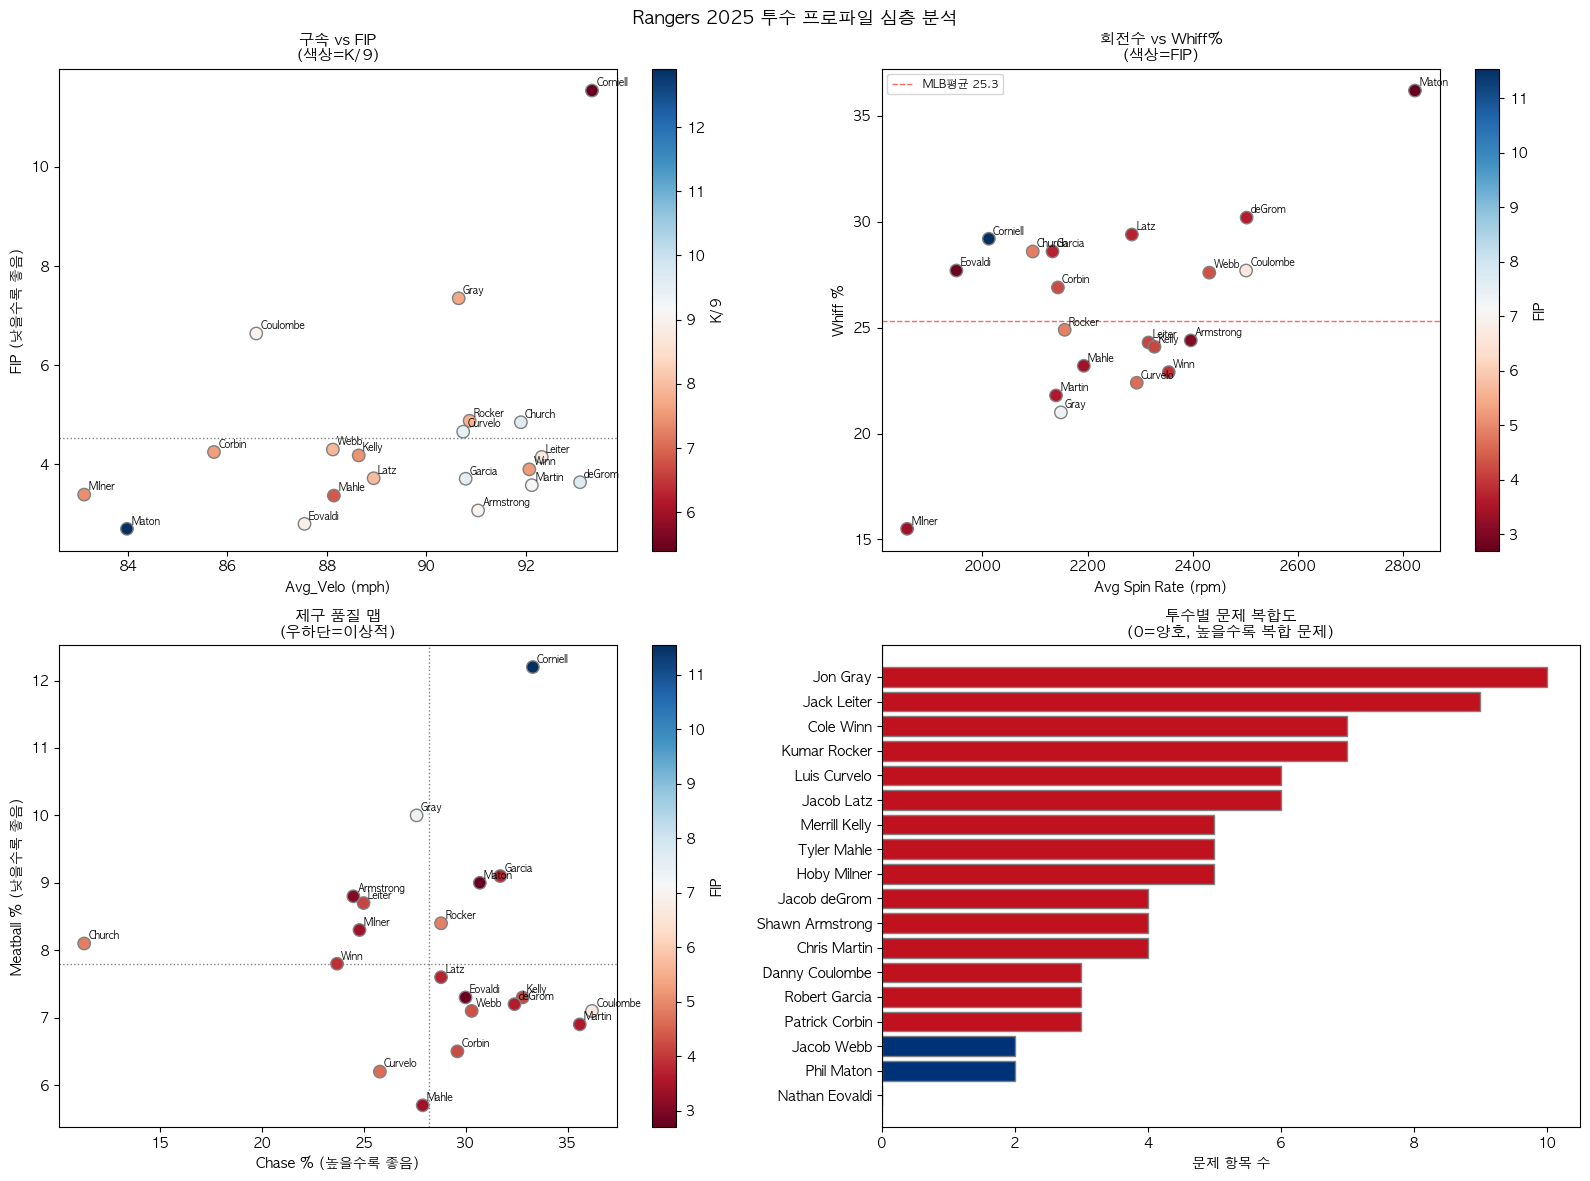

In [81]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- 좌상: FIP vs Avg_Velo (구속-실력 관계)
ax = axes[0][0]
df = pitcher[["Player","FIP","Avg_Velo","K9","GS"]].dropna()
colors = ["#C0111F" if gs > 0 else "#003278" for gs in df["GS"]]
sc = ax.scatter(df["Avg_Velo"], df["FIP"], c=df["K9"], cmap="RdBu",
                s=80, edgecolors="grey", zorder=3)
plt.colorbar(sc, ax=ax, label="K/9")
for _, row in df.iterrows():
    ax.annotate(row["Player"].split()[-1], (row["Avg_Velo"], row["FIP"]),
                fontsize=7, xytext=(3,3), textcoords="offset points")
ax.axhline(df["FIP"].mean(), color="grey", linestyle=":", linewidth=1)
ax.set_xlabel("Avg_Velo (mph)")
ax.set_ylabel("FIP (낮을수록 좋음)")
ax.set_title("구속 vs FIP\n(색상=K/9)", fontsize=11)

# --- 우상: Avg_Spin vs Whiff% (회전수-헛스윙)
ax = axes[0][1]
df2 = pitcher[["Player","Avg_Spin","Whiff %","FIP"]].dropna()
sc = ax.scatter(df2["Avg_Spin"], df2["Whiff %"], c=df2["FIP"],
                cmap="RdBu", s=80, edgecolors="grey", zorder=3)
plt.colorbar(sc, ax=ax, label="FIP")
ax.axhline(mlb_pit_avg["Whiff %"], color="red", linestyle="--", linewidth=1, alpha=0.6, label=f"MLB평균 {mlb_pit_avg["Whiff %"]}")
for _, row in df2.iterrows():
    ax.annotate(row["Player"].split()[-1], (row["Avg_Spin"], row["Whiff %"]),
                fontsize=7, xytext=(3,3), textcoords="offset points")
ax.set_xlabel("Avg Spin Rate (rpm)")
ax.set_ylabel("Whiff %")
ax.set_title("회전수 vs Whiff%\n(색상=FIP)", fontsize=11)
ax.legend(fontsize=8)

# --- 좌하: Chase% vs Meatball% (제구 품질)
ax = axes[1][0]
df3 = pitcher[["Player","Chase %","Meatball %","FIP"]].dropna()
sc = ax.scatter(df3["Chase %"], df3["Meatball %"], c=df3["FIP"],
                cmap="RdBu", s=80, edgecolors="grey", zorder=3)
plt.colorbar(sc, ax=ax, label="FIP")
ax.axvline(mlb_pit_avg["Chase %"],    color="grey", linestyle=":", linewidth=1)
ax.axhline(mlb_pit_avg["Meatball %"], color="grey", linestyle=":", linewidth=1)
for _, row in df3.iterrows():
    ax.annotate(row["Player"].split()[-1], (row["Chase %"], row["Meatball %"]),
                fontsize=7, xytext=(3,3), textcoords="offset points")
ax.set_xlabel("Chase % (높을수록 좋음)")
ax.set_ylabel("Meatball % (낮을수록 좋음)")
ax.set_title("제구 품질 맵\n(우하단=이상적)", fontsize=11)

# --- 우하: 부진원인 복합도 바차트
ax = axes[1][1]
prob_count = pitcher[pitcher["IP_f"]>=10].copy()
prob_count["문제수"] = prob_count["부진원인"].apply(
    lambda x: 0 if x=="양호" else len(x.split(",")))
prob_count = prob_count.sort_values("문제수", ascending=True)
colors_p = ["#C0111F" if n >= 3 else "#003278" if n == 2 else "#888888" if n == 1 else "#E0E0E0"
            for n in prob_count["문제수"]]
ax.barh(prob_count["Player"], prob_count["문제수"], color=colors_p, edgecolor="grey")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("문제 항목 수")
ax.set_title("투수별 문제 복합도\n(0=양호, 높을수록 복합 문제)", fontsize=11)

plt.suptitle("Rangers 2025 투수 프로파일 심층 분석", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [62]:
# 투수별 문제 복합도
print("투수 부진 원인 복합 분류 (10이닝+ 기준)")
print("=" * 55)
for _, row in pitcher[pitcher["IP_f"]>=10].sort_values("FIP").iterrows():
    issues = row["부진원인"]
    n = 0 if issues == "양호" else len(issues.split(","))
    label = f"[{n}개]" if n > 0 else "[양호]"
    print(f"{label} {row["Player"]}: {issues}")


투수 부진 원인 복합 분류 (10이닝+ 기준)
[3개] Phil Maton: BB9↑, Meatball↑, LD허용↑
[양호] Nathan Eovaldi: 양호
[4개] Shawn Armstrong: Whiff↓, Chase↓, Meatball↑, GB↓
[4개] Hoby Milner: Barrel허용↑, Whiff↓, Chase↓, Meatball↑
[5개] Tyler Mahle: Whiff↓, Chase↓, K9↓, LD허용↑, GB↓
[4개] Chris Martin: Barrel허용↑, HardHit허용↑, EV허용↑, Whiff↓
[4개] Jacob deGrom: Barrel허용↑, HardHit허용↑, EV허용↑, GB↓
[7개] Cole Winn: Barrel허용↑, HardHit허용↑, EV허용↑, Whiff↓, Chase↓, K9↓, BB9↑
[6개] Jacob Latz: HardHit허용↑, EV허용↑, K9↓, BB9↑, LD허용↑, GB↓
[4개] Robert Garcia: BB9↑, Meatball↑, LD허용↑, GB↓
[8개] Jack Leiter: Barrel허용↑, HardHit허용↑, EV허용↑, Whiff↓, Chase↓, BB9↑, Meatball↑, GB↓
[5개] Merrill Kelly: Barrel허용↑, HardHit허용↑, EV허용↑, Whiff↓, K9↓
[3개] Patrick Corbin: K9↓, LD허용↑, GB↓
[1개] Jacob Webb: GB↓
[6개] Luis Curvelo: Barrel허용↑, Whiff↓, Chase↓, BB9↑, LD허용↑, GB↓
[7개] Kumar Rocker: Barrel허용↑, HardHit허용↑, EV허용↑, Whiff↓, K9↓, Meatball↑, LD허용↑
[10개] Jon Gray: Barrel허용↑, HardHit허용↑, EV허용↑, Whiff↓, Chase↓, K9↓, BB9↑, Meatball↑, LD허용↑, GB↓


### 투수 종합 성적 + L/R 스플릿 분석

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트
font_path = "/System/Library/Fonts/Supplemental/AppleGothic.ttf"
fp = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = fp.get_name()
plt.rcParams['axes.unicode_minus'] = False

# 종합 성적
pit_all  = pd.read_csv("./data/texas_pitchers_2025.csv")
vs_right = pd.read_csv("./data/texas_2025_pitchers_vs_right.csv")
vs_left  = pd.read_csv("./data/texas_2025_pitches_vs_left.csv")

# 컬럼 정리
pit_all  = pit_all.rename(columns={"Name":"Player","K/9":"K9","BB/9":"BB9","HR/9":"HR9"})
vs_right = vs_right.rename(columns={"Name":"Player","K/9":"K9_R","BB/9":"BB9_R","HR/9":"HR9_R",
                                     "ERA":"ERA_R","FIP":"FIP_R","xFIP":"xFIP_R","GB%":"GB_R"})
vs_left  = vs_left.rename(columns={"Name":"Player","K/9":"K9_L","BB/9":"BB9_L","HR/9":"HR9_L",
                                    "ERA":"ERA_L","FIP":"FIP_L","xFIP":"xFIP_L","GB%":"GB_L"})

# 통합
df_split = vs_right[["Player","ERA_R","FIP_R","xFIP_R","K9_R","BB9_R","GB_R"]].merge(
           vs_left[["Player","ERA_L","FIP_L","xFIP_L","K9_L","BB9_L","GB_L"]], on="Player", how="outer")
df_split = df_split.merge(pit_all[["Player","IP","G","GS","SV","HLD","WAR","ERA","FIP","xERA","vFA (pi)"]],
                          on="Player", how="left")
df_split = df_split.rename(columns={"vFA (pi)":"Velo"})
df_split[["ERA_R","FIP_R","ERA_L","FIP_L","ERA","FIP","xERA","Velo","WAR"]] =     df_split[["ERA_R","FIP_R","ERA_L","FIP_L","ERA","FIP","xERA","Velo","WAR"]].round(2)

print("로드 완료:", df_split.shape)
df_split[["Player","IP","G","GS","SV","HLD","ERA","FIP","xERA","Velo","WAR"]].sort_values("WAR",ascending=False)


로드 완료: (17, 23)


,Player,IP,G,GS,SV,HLD,ERA,FIP,xERA,Velo,WAR
11,Nathan Eovaldi,130.0,22,22,0,0,1.73,2.80,3.02,94.36,3.73
7,Jacob deGrom,172.2,30,30,0,0,2.97,3.64,3.36,97.57,3.39
4,Jack Leiter,151.2,29,29,0,0,3.86,4.15,4.45,97.38,2.26
16,Tyler Mahle,86.2,16,16,0,0,2.18,3.37,4.23,92.26,1.93
12,Patrick Corbin,155.1,31,30,0,0,4.40,4.25,4.75,91.49,1.87
15,Shawn Armstrong,74.0,71,2,9,12,2.31,3.07,3.02,93.64,1.35
5,Jacob Latz,85.2,33,8,1,1,2.84,3.72,4.11,94.30,1.26
3,Hoby Milner,70.1,73,0,0,18,3.84,3.39,3.79,88.02,0.96
10,Merrill Kelly,55.1,10,10,0,0,4.23,4.18,4.39,91.55,0.78
13,Phil Maton,23.0,23,0,3,2,3.52,2.70,3.34,NaN,0.57


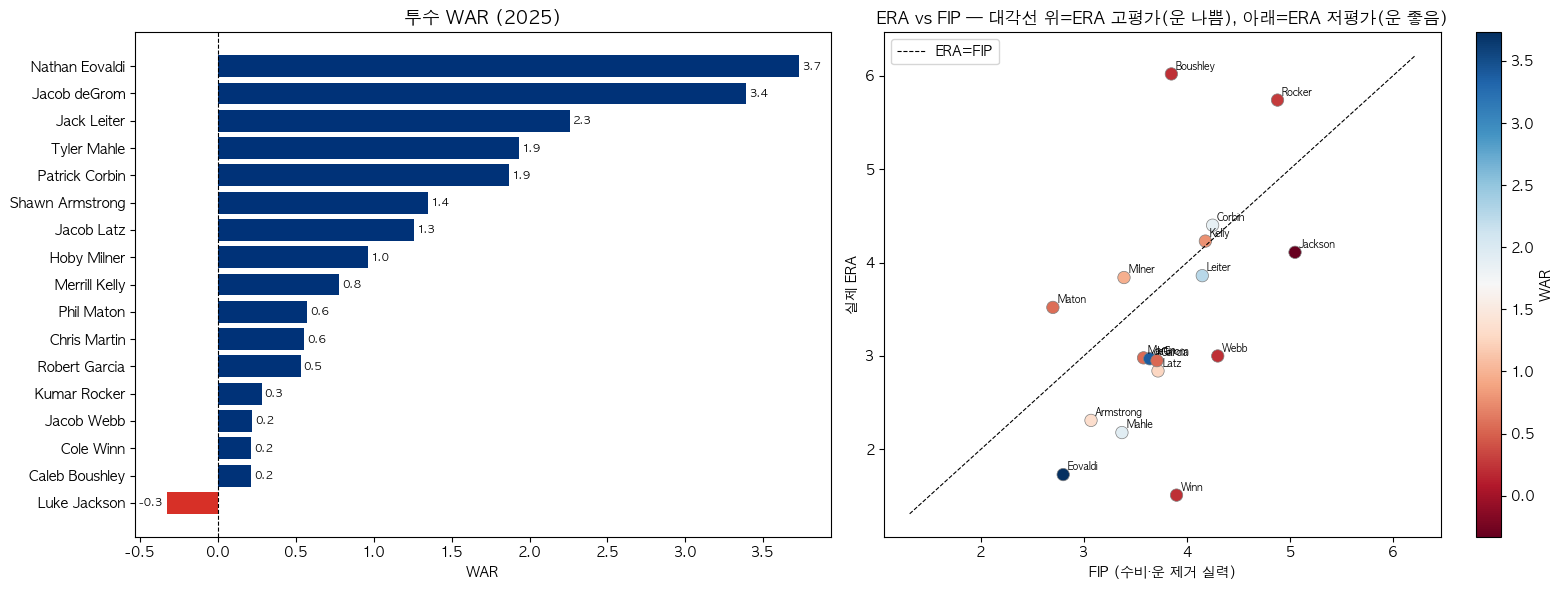

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_war = df_split.dropna(subset=["WAR"]).sort_values("WAR")

# 좌: WAR 막대
colors_war = ["#d73027" if w < 0 else "#003278" for w in df_war["WAR"]]
axes[0].barh(df_war["Player"], df_war["WAR"], color=colors_war)
axes[0].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("투수 WAR (2025)", fontproperties=fp, fontsize=13)
axes[0].set_xlabel("WAR", fontproperties=fp)
for i, (p, w) in enumerate(zip(df_war["Player"], df_war["WAR"])):
    axes[0].text(w + 0.02 if w >= 0 else w - 0.02, i,
                 f"{w:.1f}", va='center', ha='left' if w >= 0 else 'right', fontsize=8)

# 우: ERA vs FIP 산점도
df_ef = df_split.dropna(subset=["ERA","FIP"])
sc = axes[1].scatter(df_ef["FIP"], df_ef["ERA"],
                     c=df_ef["WAR"], cmap="RdBu", s=80, edgecolors='grey', linewidths=0.5)
plt.colorbar(sc, ax=axes[1], label="WAR")
lim_min = min(df_ef["FIP"].min(), df_ef["ERA"].min()) - 0.2
lim_max = max(df_ef["FIP"].max(), df_ef["ERA"].max()) + 0.2
axes[1].plot([lim_min, lim_max], [lim_min, lim_max], "k--", linewidth=0.8, label="ERA=FIP")
axes[1].set_xlabel("FIP (수비·운 제거 실력)", fontproperties=fp)
axes[1].set_ylabel("실제 ERA", fontproperties=fp)
axes[1].set_title("ERA vs FIP — 대각선 위=ERA 고평가(운 나쁨), 아래=ERA 저평가(운 좋음)", fontproperties=fp, fontsize=12)
for _, row in df_ef.iterrows():
    axes[1].annotate(row["Player"].split()[-1], (row["FIP"], row["ERA"]),
                     fontsize=7, xytext=(3,3), textcoords="offset points")
axes[1].legend(prop=fp)

plt.tight_layout()
plt.show()

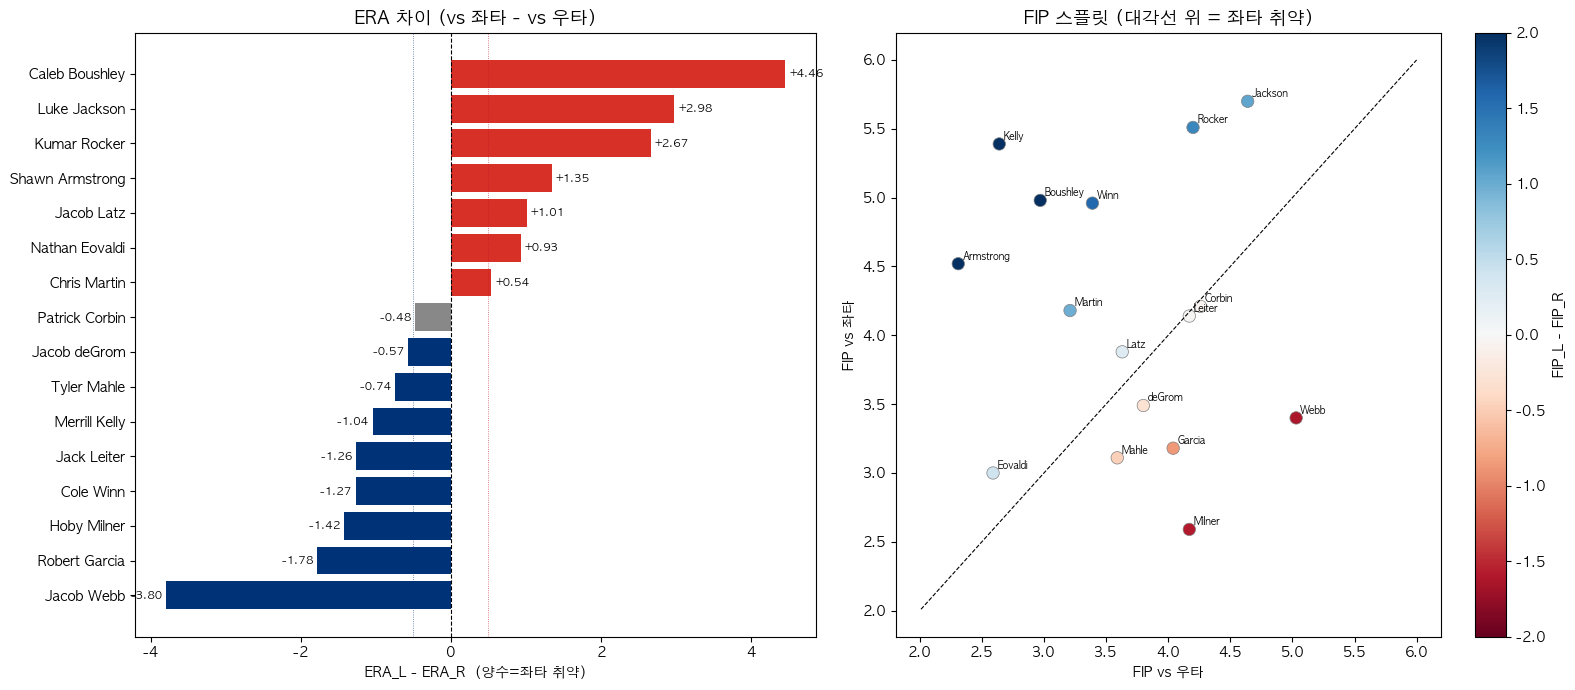

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

df_lr = df_split.dropna(subset=["ERA_R","ERA_L"]).copy()
df_lr["ERA_diff"] = df_lr["ERA_L"] - df_lr["ERA_R"]   # 양수 = 좌타에 더 취약
df_lr = df_lr.sort_values("ERA_diff")

colors_lr = ["#d73027" if d > 0.5 else "#003278" if d < -0.5 else "#888888"
             for d in df_lr["ERA_diff"]]

# 좌: ERA_L - ERA_R 차이
axes[0].barh(df_lr["Player"], df_lr["ERA_diff"], color=colors_lr)
axes[0].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].axvline(0.5,  color="#C0111F", linewidth=0.6, linestyle=":", alpha=0.7)
axes[0].axvline(-0.5, color="#003278", linewidth=0.6, linestyle=":", alpha=0.7)
axes[0].set_title("ERA 차이 (vs 좌타 - vs 우타)", fontproperties=fp, fontsize=13)
axes[0].set_xlabel("ERA_L - ERA_R  (양수=좌타 취약)", fontproperties=fp)
for i, (p, d) in enumerate(zip(df_lr["Player"], df_lr["ERA_diff"])):
    axes[0].text(d + 0.05 if d >= 0 else d - 0.05, i,
                 f"{d:+.2f}", va='center', ha='left' if d >= 0 else 'right', fontsize=8)

# 우: FIP_R vs FIP_L 산점도
df_fip = df_split.dropna(subset=["FIP_R","FIP_L"])
sc2 = axes[1].scatter(df_fip["FIP_R"], df_fip["FIP_L"],
                      c=df_fip["FIP_L"]-df_fip["FIP_R"], cmap="RdBu", s=80,
                      edgecolors='grey', linewidths=0.5, vmin=-2, vmax=2)
plt.colorbar(sc2, ax=axes[1], label="FIP_L - FIP_R")
lf = max(df_fip["FIP_R"].max(), df_fip["FIP_L"].max()) + 0.3
ls = min(df_fip["FIP_R"].min(), df_fip["FIP_L"].min()) - 0.3
axes[1].plot([ls, lf], [ls, lf], "k--", linewidth=0.8)
axes[1].set_xlabel("FIP vs 우타", fontproperties=fp)
axes[1].set_ylabel("FIP vs 좌타", fontproperties=fp)
axes[1].set_title("FIP 스플릿 (대각선 위 = 좌타 취약)", fontproperties=fp, fontsize=13)
for _, row in df_fip.iterrows():
    axes[1].annotate(row["Player"].split()[-1], (row["FIP_R"], row["FIP_L"]),
                     fontsize=7, xytext=(3,3), textcoords="offset points")

plt.tight_layout()
plt.show()


In [88]:
print("=" * 60)
print("[ L/R 스플릿 취약 방향 진단 ]")
print("  기준: ERA 차이 > 0.5 = 취약, K/9 차이 > 1.0 = 삼진 편차 큼")
print("=" * 60)

df_diag = df_split.dropna(subset=["ERA_R","ERA_L","K9_R","K9_L"]).copy()
df_diag["ERA_diff"] = (df_diag["ERA_L"] - df_diag["ERA_R"]).round(2)
df_diag["K9_diff"]  = (df_diag["K9_L"]  - df_diag["K9_R"]).round(2)

for _, row in df_diag.sort_values("ERA_diff", ascending=False).iterrows():
    tags = []
    if row["ERA_diff"] >  0.5: tags.append("좌타취약")
    if row["ERA_diff"] < -0.5: tags.append("우타취약")
    if row["K9_diff"]  >  1.0: tags.append("좌타K↑")
    if row["K9_diff"]  < -1.0: tags.append("우타K↑")
    label = f"[{'|'.join(tags)}]" if tags else "     균형"
    ip_info = f"IP={row['IP']:.0f}" if pd.notna(row.get('IP')) else ""
    print(f"{label:<20} {row['Player']:<20}  ERA: {row['ERA_L']:.2f}(좌) / {row['ERA_R']:.2f}(우)  {ip_info}")


[ L/R 스플릿 취약 방향 진단 ]
  기준: ERA 차이 > 0.5 = 취약, K/9 차이 > 1.0 = 삼진 편차 큼
[좌타취약|좌타K↑]          Caleb Boushley        ERA: 8.53(좌) / 4.07(우)  IP=43
[좌타취약]               Luke Jackson          ERA: 5.93(좌) / 2.95(우)  IP=35
[좌타취약|우타K↑]          Kumar Rocker          ERA: 7.02(좌) / 4.35(우)  IP=64
[좌타취약]               Shawn Armstrong       ERA: 3.20(좌) / 1.85(우)  IP=74
[좌타취약|우타K↑]          Jacob Latz            ERA: 3.48(좌) / 2.47(우)  IP=85
[좌타취약]               Nathan Eovaldi        ERA: 2.19(좌) / 1.26(우)  IP=130
[좌타취약|우타K↑]          Chris Martin          ERA: 3.31(좌) / 2.77(우)  IP=42
     균형              Patrick Corbin        ERA: 4.05(좌) / 4.53(우)  IP=155
[우타취약|좌타K↑]          Jacob deGrom          ERA: 2.69(좌) / 3.26(우)  IP=172
[우타취약|좌타K↑]          Tyler Mahle           ERA: 1.79(좌) / 2.53(우)  IP=86
[우타취약|우타K↑]          Merrill Kelly         ERA: 3.77(좌) / 4.81(우)  IP=55
[우타취약]               Jack Leiter           ERA: 3.26(좌) / 4.52(우)  IP=151
[우타취약]               Cole Winn             ERA: 0.6

## 핵심 타자 개인 심층 분석 — 월별 성적 + 부상 전후 비교

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches

font_path = "/System/Library/Fonts/Supplemental/AppleGothic.ttf"
fp = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = fp.get_name()
plt.rcParams['axes.unicode_minus'] = False

batter_gl = pd.read_csv("./data/rangers_batter_gamelogs.csv")
batter_gl["Date"] = pd.to_datetime(batter_gl["Date"])
batter_gl["Month"] = batter_gl["Date"].dt.month
batter_gl["ISO"] = batter_gl["game_SLG"] - batter_gl["game_AVG"]

# 분석 대상
targets = ["Corey Seager", "Evan Carter", "Wyatt Langford", "Marcus Semien"]

# 부상 타임라인
injury_dates = {
    "Corey Seager":   [("2025-04-22", "햄스트링(출전제한)"), ("2025-09-01", "수술이탈")],
    "Evan Carter":    [("2025-05-10", "허벅지부상"), ("2025-08-21", "손목골절")],
    "Wyatt Langford": [("2025-09-21", "복사근부상")],
    "Marcus Semien":  [("2025-09-05", "발부상(IL)")],
}

month_labels = {3:"3월", 4:"4월", 5:"5월", 6:"6월", 7:"7월", 8:"8월", 9:"9월"}

def monthly_stats(name):
    d = batter_gl[batter_gl["name"] == name].copy()
    grp = d.groupby("Month").agg(
        G=("PA","count"),
        PA=("PA","sum"),
        H=("H","sum"),
        AB=("AB","sum"),
        HR=("HR","sum"),
        BB=("BB","sum"),
        SO=("SO","sum"),
        TB=("game_SLG", lambda x: (x * d.loc[x.index,"AB"]).sum()),
    ).reset_index()
    grp["AVG"]  = (grp["H"]  / grp["AB"]).round(3)
    grp["OBP"]  = ((grp["H"] + grp["BB"]) / grp["PA"]).round(3)
    grp["SLG"]  = (grp["TB"] / grp["AB"]).round(3)
    grp["OPS"]  = (grp["OBP"] + grp["SLG"]).round(3)
    grp["ISO"]  = (grp["SLG"] - grp["AVG"]).round(3)
    grp["BB%"]  = (grp["BB"] / grp["PA"] * 100).round(1)
    grp["K%"]   = (grp["SO"] / grp["PA"] * 100).round(1)
    grp["월"] = grp["Month"].map(month_labels)
    return grp[["월","G","PA","AVG","OBP","SLG","OPS","ISO","HR","BB%","K%"]]

print("=" * 60)
for name in targets:
    print(f"\n[ {name} ]")
    print(monthly_stats(name).to_string(index=False))
    print()



[ Corey Seager ]
 월  G  PA   AVG   OBP   SLG   OPS   ISO  HR  BB%   K%
3월  4  15 0.214 0.267 0.214 0.481 0.000   0  6.7 26.7
4월 17  69 0.302 0.362 0.524 0.886 0.222   4  8.7 15.9
5월  8  35 0.286 0.286 0.514 0.800 0.228   2  0.0 22.9
6월 24 111 0.188 0.342 0.353 0.695 0.165   4 19.8 19.8
7월 24 108 0.326 0.426 0.596 1.022 0.270   5 15.7 23.1
8월 25 107 0.277 0.355 0.511 0.866 0.234   6 11.2 15.9


[ Evan Carter ]
 월  G  PA   AVG   OBP   SLG   OPS   ISO  HR  BB%   K%
5월 11  37 0.182 0.243 0.273 0.516 0.091   1  8.1 16.2
6월 21  76 0.333 0.395 0.530 0.925 0.197   3 10.5 15.8
7월 22  72 0.185 0.250 0.308 0.558 0.123   0  8.3 25.0
8월  9  35 0.267 0.286 0.400 0.686 0.133   1  5.7 14.3


[ Wyatt Langford ]
 월  G  PA   AVG   OBP   SLG   OPS   ISO  HR  BB%   K%
3월  5  20 0.263 0.300 0.421 0.721 0.158   1  5.0 15.0
4월 16  68 0.310 0.382 0.655 1.037 0.345   5 11.8 20.6
5월 28 120 0.189 0.275 0.349 0.624 0.160   5 10.8 28.3
6월 18  84 0.224 0.274 0.342 0.616 0.118   2  7.1 29.8
7월 22  90 0.266 0.356 0.4

In [90]:
# 부상 전후 구간 성적 비교
injury_splits = {
    "Corey Seager": [
        ("시즌초(정상)", "2025-03-27", "2025-04-21"),
        ("햄스트링 이후", "2025-04-22", "2025-08-31"),
        ("수술 이탈 전", "2025-06-01", "2025-08-31"),
    ],
    "Evan Carter": [
        ("부상 전(허벅지)", "2025-03-27", "2025-05-09"),
        ("복귀 후", "2025-06-01", "2025-08-20"),
        ("손목골절 이탈", "2025-08-21", "2025-09-28"),
    ],
    "Wyatt Langford": [
        ("전반기", "2025-03-27", "2025-07-13"),
        ("후반기(부상전)", "2025-07-14", "2025-09-20"),
        ("복사근 이탈", "2025-09-21", "2025-09-28"),
    ],
    "Marcus Semien": [
        ("전반기", "2025-03-27", "2025-07-13"),
        ("후반기(부상전)", "2025-07-14", "2025-09-04"),
        ("발부상 IL", "2025-09-05", "2025-09-28"),
    ],
}

def split_stats(name, label, s, e):
    d = batter_gl[(batter_gl["name"]==name) &
                  (batter_gl["Date"]>=s) & (batter_gl["Date"]<=e)]
    if len(d) == 0:
        return None
    pa = d["PA"].sum(); ab = d["AB"].sum()
    h  = d["H"].sum();  hr = d["HR"].sum()
    bb = d["BB"].sum(); so = d["SO"].sum()
    tb = (d["game_SLG"] * d["AB"]).sum()
    avg = round(h/ab,3) if ab>0 else 0
    obp = round((h+bb)/pa,3) if pa>0 else 0
    slg = round(tb/ab,3) if ab>0 else 0
    iso = round(slg-avg,3)
    return {"구간":label,"G":len(d),"PA":pa,"AVG":avg,"OBP":obp,
            "SLG":slg,"OPS":round(obp+slg,3),"ISO":iso,"HR":hr,
            "BB%":round(bb/pa*100,1),"K%":round(so/pa*100,1)}

print("=" * 70)
for name, splits in injury_splits.items():
    print(f"\n[ {name} ] 구간별 성적")
    rows = [split_stats(name, *s) for s in splits]
    rows = [r for r in rows if r]
    if rows:
        print(pd.DataFrame(rows).to_string(index=False))



[ Corey Seager ] 구간별 성적
     구간  G  PA   AVG   OBP   SLG   OPS   ISO  HR  BB%   K%
시즌초(정상) 20  80 0.288 0.350 0.479 0.829 0.191   4  8.8 18.8
햄스트링 이후 82 365 0.267 0.364 0.489 0.853 0.222  17 14.0 19.7
수술 이탈 전 73 326 0.265 0.374 0.489 0.863 0.224  15 15.6 19.6

[ Evan Carter ] 구간별 성적
       구간  G  PA   AVG   OBP   SLG   OPS   ISO  HR  BB%   K%
부상 전(허벅지)  4  14 0.214 0.214 0.214 0.428 0.000   0  0.0  7.1
     복귀 후 51 179 0.258 0.318 0.415 0.733 0.157   4  8.9 19.6
  손목골절 이탈  1   4 0.500 0.250 0.500 0.750 0.000   0  0.0  0.0

[ Wyatt Langford ] 구간별 성적
      구간  G  PA   AVG   OBP   SLG   OPS   ISO  HR  BB%   K%
     전반기 76 332 0.242 0.316 0.433 0.749 0.191  15 10.2 26.2
후반기(부상전) 56 235 0.240 0.357 0.417 0.774 0.177   6 16.2 26.8
  복사근 이탈  2   6 0.250 0.500 1.000 1.500 0.750   1 33.3 16.7

[ Marcus Semien ] 구간별 성적
      구간  G  PA   AVG   OBP   SLG   OPS   ISO  HR  BB%   K%
     전반기 96 401 0.239 0.309 0.378 0.687 0.139  12 10.0 19.0
후반기(부상전) 31 133 0.203 0.256 0.322 0.578 0.119   3  7.5 12.

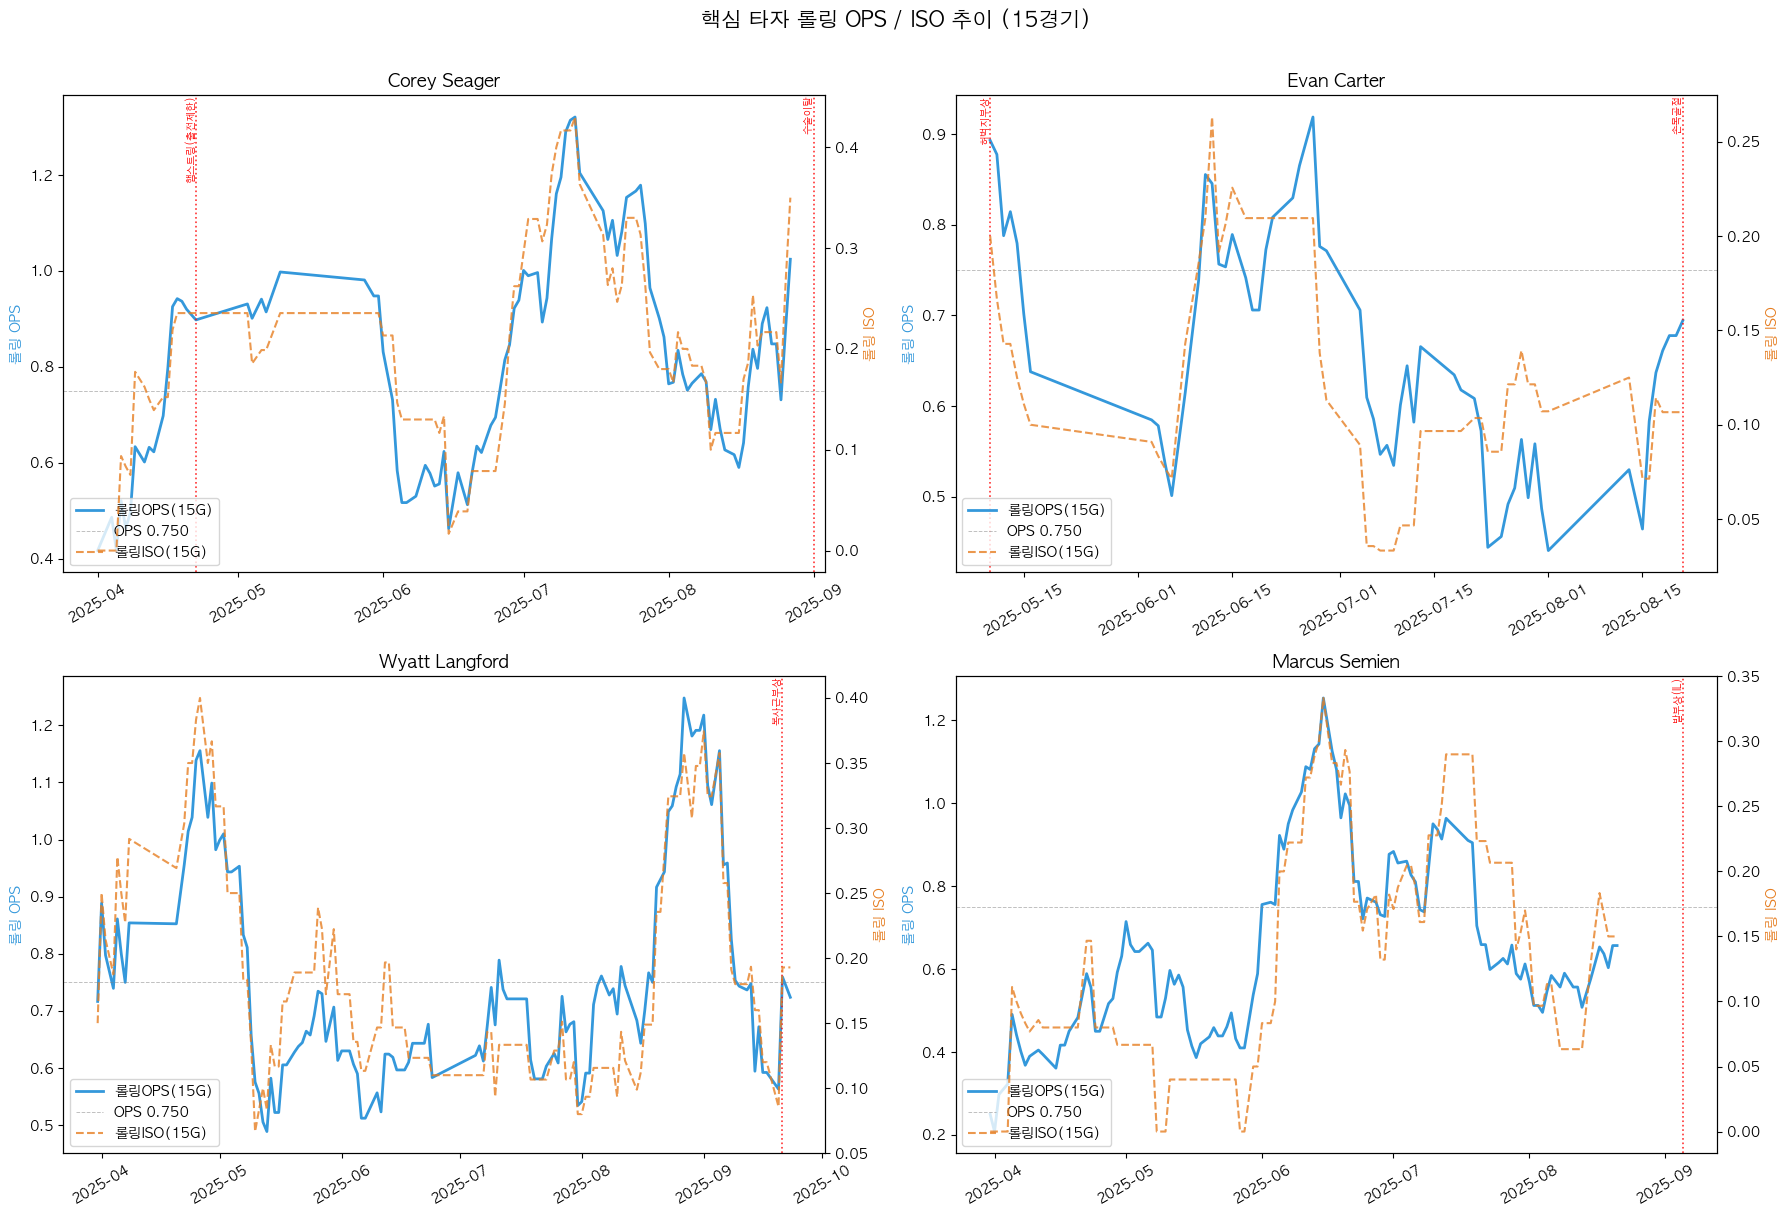

In [92]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

def rolling_ops(name, window=15):
    d = batter_gl[batter_gl["name"]==name].sort_values("Date").copy()
    d["roll_OPS"] = d["game_OPS"].rolling(window, min_periods=5).mean()
    d["roll_ISO"] = (d["game_SLG"] - d["game_AVG"]).rolling(window, min_periods=5).mean()
    return d

for idx, name in enumerate(targets):
    ax = axes[idx]
    d = rolling_ops(name)
    ax2 = ax.twinx()

    ax.plot(d["Date"], d["roll_OPS"], color="#3498db", linewidth=2, label="롤링OPS(15G)")
    ax2.plot(d["Date"], d["roll_ISO"], color="#e67e22", linewidth=1.5,
             linestyle="--", alpha=0.8, label="롤링ISO(15G)")

    # 부상 마커
    for date_str, label in injury_dates.get(name, []):
        dt = pd.Timestamp(date_str)
        ax.axvline(dt, color="red", linewidth=1.2, linestyle=":", alpha=0.8)
        ax.text(dt, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1.2,
                label, rotation=90, fontsize=7, color="red",
                va="top", ha="right", fontproperties=fp)

    ax.axhline(0.750, color="gray", linewidth=0.7, linestyle="--", alpha=0.5, label="OPS 0.750")
    ax.set_title(name, fontproperties=fp, fontsize=13)
    ax.set_ylabel("롤링 OPS", fontproperties=fp, color="#3498db")
    ax2.set_ylabel("롤링 ISO", fontproperties=fp, color="#e67e22")
    ax.tick_params(axis='x', rotation=30)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, labels1+labels2, prop=fp, fontsize=8, loc="lower left")

plt.suptitle("핵심 타자 롤링 OPS / ISO 추이 (15경기)", fontproperties=fp, fontsize=15, y=1.01)
plt.tight_layout()
plt.show()


---
## EDA 종합 결론 — Texas Rangers 2025

### 1. 시즌 구조 요약

| 구간 | 기간 | 승패 | 득실차 | 핵심 원인 |
|---|---|---|---|---|
| 시즌초(건강) | 3/27~4/21 | 정상 가동 | 양호 | 풀전력 |
| 5월 부진 | 5월 | 12승 16패 | +5 | 타격코치 교체 + Seager/Carter 부상, 클러치 극약 |
| 전원복귀 | 6~8/20 | 승률 0.465 | — | 불펜 구조 문제, 클러치 여전히 약 |
| 연쇄부상 붕괴 | 8/21~ | 10승 13패 | -12 | Eovaldi·Seager·Carter·Semien 연쇄 이탈 |

> **역설**: 전원 복귀 구간(6~8월)에도 승률 0.465 → 부상 외에도 구조적 문제 존재


### 2. 타선 진단

**만성 문제**
- **클러치 극약** — 5월 득실 +5인데 16패, WPA/RE24 하위권 다수
- **Semien 전반기 부진** — 3~5월 OPS 0.554 수준, 팀 중심타자로서 타선 분위기 저하
- **Langford K% 과다** — 5~6월 K% 28~30%, 슬럼프 구간 삼진이 핵심 원인
- **wRC+ 하위 타자 다수** — 선구안 문제(Chase↑/Whiff↑)와 파워 부족(Barrel↓) 복합
- **HR 의존도 과다** — HR 있는 경기 승률 0.598 vs 없는 경기 0.259, 차이가 과도하게 큼

**긍정 요소**
- Seager 햄스트링 부상에도 OPS 0.853 유지, 7월 OPS 1.022 피크
  - 단, Clutch -1.531(타자 최하위) — 고압 상황에서 유독 약했음
- Langford 8월 OPS 0.928 반등 — 잠재력 확인
- Carter 6월 OPS 0.925 — 건강할 때 상위권 성적


### 3. 투수진 진단

**선발**
- Eovaldi + deGrom **2인 의존 구조** — WAR 합계 7.12, 나머지 전체 합계와 비슷
- 두 에이스 모두 부상 이탈 → 9월 득실 -12 직결
- Leiter: BB9 높음(만성 제구 이슈) / Corbin: ERA 4.40 약체 선발 / Rocker: ERA 5.74 부진
- **Cole Winn ERA 1.51 vs FIP 3.90** — 행운 폭 최대, 2026 하락 리스크 가장 높은 투수

**불펜**
- **마무리 미확정** — Garcia·Armstrong 9세이브씩 분담, 역할 불명확
- **Garcia Clutch -1.164(투수 최하위)** — ERA 2.95로 보이지만 고압 상황 실제 최약체, 마무리 적합성 의문
- Webb ERA 3.00 vs FIP 4.30 — 행운, 하반기 회귀 리스크
- Luke Jackson — 유일한 음수 WAR(-0.33), 구조적 약점

**긍정 요소**
- Armstrong 불펜 최고 안정 (ERA 2.31, WAR 1.35, Clutch 0.867)
- Maton FIP 2.70 — ERA보다 실력 더 좋음
- Eovaldi 건강 구간 ERA 1.73 — 리그 최상위 (Clutch 0.648)


### 4. 핵심 발견 요약

1. **에이스 2인 의존 + 연쇄 부상** → 9월 붕괴의 직접 원인
2. **클러치 구조적 약점** → 득실 플러스에도 승률이 낮은 구간 반복
3. **불펜 마무리 불명확 + Garcia 클러치 최하위** → 세이브 기회 관리 비효율
4. **타선 중심 Semien 부진** → 팀 전반기 득점력 저하
5. **Langford K% 이슈** → 잠재력 대비 성적 편차 큼
6. **HR 의존 타선** → HR 없는 경기 승률 0.259, 득점 다양성 부족
7. **Cole Winn 2026 회귀 리스크** — ERA 1.51 vs FIP 3.90, 행운 폭 최대
8. **접전 경기(1-2점차) 승률 0.436** — 시즌 78경기(48%)가 접전, 절반도 못 이김
9. **원정 접전 승률 0.278** — 홈(0.571) 대비 극심한 격차, 구조적 약점
10. **상대 마무리에게 막힌 경기(29) > Rangers 마무리 세이브(24)** — 접전에서 리드를 잡는 빈도 자체가 낮았음, 공격력 부족 또는 선발/불펜이 리드를 만들어주지 못한 구조적 문제

### 5. 이후 분석 방향 (별도)
- MediaPipe 기반 스윙/투구 모션 분석 (파이프라인 보완 후)
- 분석 후보 
    
    타자:
    - Langford (K% 스윙 문제)
    - Jung (부상 복귀 후 메커니즘 변화)
    
    투수:
    - Leiter (제구 릴리스 포인트)
    - Winn (ERA vs FIP 괴리)
- 타자 vs 좌투/우투 스플릿
- 불펜 운용 패턴 (등판 간격, 연투 영향)


In [71]:
import pandas as pd

summary = {
    "구분": [
        "투수", "투수", "투수", "투수",
        "타선", "타선", "타선", "타선",
        "팀 성적", "팀 성적"
    ],
    "항목": [
        "시즌 WAR 1위", "시즌 WAR 2위",
        "불펜 최다 홀드", "마무리(공동)",
        "최고 월 OPS", "최저 월 OPS",
        "ERA < FIP (행운)", "FIP < ERA (저평가)",
        "5월 승패 (득실 +5)", "9월 승패 (득실 -12)"
    ],
    "내용": [
        "Eovaldi — WAR 3.73, ERA 1.73",
        "deGrom — WAR 3.39, ERA 2.97",
        "Hoby Milner — 18홀드",
        "Garcia / Armstrong — 각 9세이브",
        "Seager 7월 1.022 / Langford 4월 1.037",
        "Semien 3월 0.255 / Langford 5월 0.624",
        "Webb (3.00 vs 4.30), Winn (1.51 vs 3.90)",
        "Maton (3.52 vs 2.70), Eovaldi (1.73 vs 2.80)",
        "12승 16패 — 클러치 극약",
        "10승 13패 — 연쇄 부상 붕괴"
    ]
}

df_sum = pd.DataFrame(summary)
display(df_sum.style
        .set_caption("Texas Rangers 2025 — EDA 핵심 지표 요약")
        .set_properties(**{'text-align': 'left', 'font-size': '12px'})
        .hide(axis='index'))


구분,항목,내용
투수,시즌 WAR 1위,"Eovaldi — WAR 3.73, ERA 1.73"
투수,시즌 WAR 2위,"deGrom — WAR 3.39, ERA 2.97"
투수,불펜 최다 홀드,Hoby Milner — 18홀드
투수,마무리(공동),Garcia / Armstrong — 각 9세이브
타선,최고 월 OPS,Seager 7월 1.022 / Langford 4월 1.037
타선,최저 월 OPS,Semien 3월 0.255 / Langford 5월 0.624
타선,ERA < FIP (행운),"Webb (3.00 vs 4.30), Winn (1.51 vs 3.90)"
타선,FIP < ERA (저평가),"Maton (3.52 vs 2.70), Eovaldi (1.73 vs 2.80)"
팀 성적,5월 승패 (득실 +5),12승 16패 — 클러치 극약
팀 성적,9월 승패 (득실 -12),10승 13패 — 연쇄 부상 붕괴


## Markov Chain 게임 시뮬

- [타자별 이벤트 확률 추출]
  - xwOBA, K%, BB%, Barrel% → 1B/2B/3B/HR/BB/K 확률

- [Markov Chain 경기 시뮬]
  - base-out state (24가지) 전이
  → 1경기 득점 시뮬

- [시나리오 적용]
  - 불펜 개선 → 후반 실점 확률 조정
  - 원정 보정 → 타자 확률에 원정 페널티

- [Monte Carlo]
  - 시즌 162경기 × 1000번
  → 기대 승리 분포


## 야구 시뮬레이션 모델 정리 

---

 1. Markov Chain 
  - base-out state 전이
  - 장점: 직관적, 계산 빠름
  - 단점: 타자 순서 무시, 주자 이동 단순화

--- 

 2. Play-by-Play 시뮬레이션
  - 타석 하나하나를 직접 샘플링
  - 실제 경기 흐름과 가장 유사
  - 장점: 타순 효과, 투수 교체 반영 가능
  - 단점: 데이터 많이 필요, 구현 복잡

---

3. Pythagorean Expectation

  - 기대 승률 = R² / (R² + RA²)
  - 가장 단순한 방법
  - 장점: 계산 즉시 가능, 지금 데이터로 바로 가능
  - 단점: 경기 내부 구조 무시

---

4. Log5 / 확률 매칭
  - 타자 성적 vs 투수 성적 매칭해서 결과 확률 계산
  - 장점: 개인 대 개인 매칭 가능
  - 단점: 구장/홈어웨이 보정 필요